# load datasets

In [43]:
# Notebook setup: install only packages missing from the active Jupyter kernel
import sys, subprocess, importlib.util

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "statsmodels": "statsmodels",
}
missing = [pip_name for module, pip_name in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are available.")


All required packages are available.


In [44]:
import pandas as pd
import numpy as np 
MATURITY_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]

# ─────────────────────────────────────────────
# Dataset paths
# ─────────────────────────────────────────────

historical_data = "raw_data.csv"
current_diffusion = r"last run 18-5/18-5 diffusion 1 start curve.csv"
VAE_data = r"last run 18-5/18-5 VAE 1 start curve right format.csv"  
hjm_data = r"last run 18-5/18-5 hjm-pca 1 start curve.csv"  

# All generated scenario files are capped at 200 scenarios
N_SCENARIOS = 200

_SCENARIO_CACHE = {}

def load_scenarios(path, n_scen=N_SCENARIOS):
    """
    Load a generated-scenario csv (Scenario_ID, Month, Y_1M … Y_30Y)
    and keep the first `n_scen` scenarios.
    """
    key = (path, n_scen)
    if key not in _SCENARIO_CACHE:
        df = pd.read_csv(path)
        keep_ids = df["Scenario_ID"].drop_duplicates().iloc[:n_scen]
        cached = df[df["Scenario_ID"].isin(keep_ids)].copy()
        cached = cached.sort_values(["Scenario_ID", "Month"]).reset_index(drop=True)
        _SCENARIO_CACHE[key] = cached
    return _SCENARIO_CACHE[key]

# Registry of every generative model — used by the comparison loops further down
MODELS = {
    "Diffusion": current_diffusion,
    "HJM-PCA":   hjm_data,
    "VAE":       VAE_data,
}


# Visualising and preparing Historical Data
- We visualise NS factors and volatility trough time
- We preprosess the historical data: transform to monthly data and create rolling windows of 5 years shifting each month

## Preprossessing historical data

In [45]:
# ─────────────────────────────────────────────
# Historical-data preparation
# ─────────────────────────────────────────────
# The historical CSV contains daily observations of the yield curve plus three
# macro columns (FedFunds, CPI_Level, Real_GDP). For the evaluation we need:
#   1. daily → monthly data (end-of-month value)
#   2. drop the three macro columns so only the yield curve remains
#   3. build rolling windows of 60 timesteps, shifting by 1 month each time
#      (comparable to the 60-month generated scenarios)
#
# `prepare_historical_data` is the single entry point used everywhere in this
# notebook whenever we need the monthly historical data or rolling windows.

HIST_YIELD_COLS = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y", "Yield_2Y",
    "Yield_3Y", "Yield_5Y", "Yield_7Y", "Yield_10Y", "Yield_20Y", "Yield_30Y",
]
MACRO_COLS   = ["FedFunds", "CPI_Level", "Real_GDP"]
WINDOW_SIZE  = 60     # rolling window length (months) — matches scenario horizon
WINDOW_STEP  = 1      # shift by 1 month (rolling, not tumbling)


def prepare_historical_data(path=historical_data,
                            window=WINDOW_SIZE,
                            step=WINDOW_STEP):
    """
    Transform the raw historical CSV into the objects used by every
    evaluation section.

    Steps
    -----
    1. Parse DATE, sort, set as index.
    2. Resample daily → monthly (end-of-month) keeping the last observation
       of every month.
    3. Drop the three macro columns (FedFunds, CPI_Level, Real_GDP); only
       the 11 yield-curve columns remain.
    4. Build rolling windows of `window` months shifted by `step` months.

    Returns
    -------
    hist_monthly : pd.DataFrame
        (n_months, 11) — monthly yield curve, indexed by month-end DATE.
    hist_windows : np.ndarray
        (n_windows, window, 11) — rolling windows of the monthly data.
    """
    # 1. load
    df = pd.read_csv(path, parse_dates=["DATE"])
    df = df.set_index("DATE").sort_index()

    # 2. daily → monthly (end-of-month: last observation per month)
    monthly = df.resample("ME").last()

    # 3. drop the three macro columns — keep only the yield curve
    monthly = monthly.drop(columns=MACRO_COLS, errors="ignore")
    monthly = monthly[HIST_YIELD_COLS].dropna()

    # 4. rolling windows of `window` months, shift = `step`
    arr = monthly.values                 # (n_months, 11)
    n   = len(arr)
    if n < window:
        raise ValueError(f"Only {n} monthly observations; need at least {window}.")
    windows = np.stack([arr[s:s + window]
                        for s in range(0, n - window + 1, step)])
    return monthly, windows


# Run once and expose the results as module-level globals so every downstream
# cell can reuse them without re-loading or re-resampling the raw csv.
hist_monthly, hist_windows = prepare_historical_data()

print(f"Historical monthly observations : {hist_monthly.shape[0]}  "
      f"({hist_monthly.index[0].strftime('%Y-%m')} → "
      f"{hist_monthly.index[-1].strftime('%Y-%m')})")
print(f"Columns retained                : {list(hist_monthly.columns)}")
print(f"Rolling windows (60m, step 1)   : {hist_windows.shape}  "
      f"(n_windows, window, n_maturities)")


Historical monthly observations : 290  (2002-01 → 2026-02)
Columns retained                : ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y', 'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']
Rolling windows (60m, step 1)   : (231, 60, 11)  (n_windows, window, n_maturities)


# Comparing models

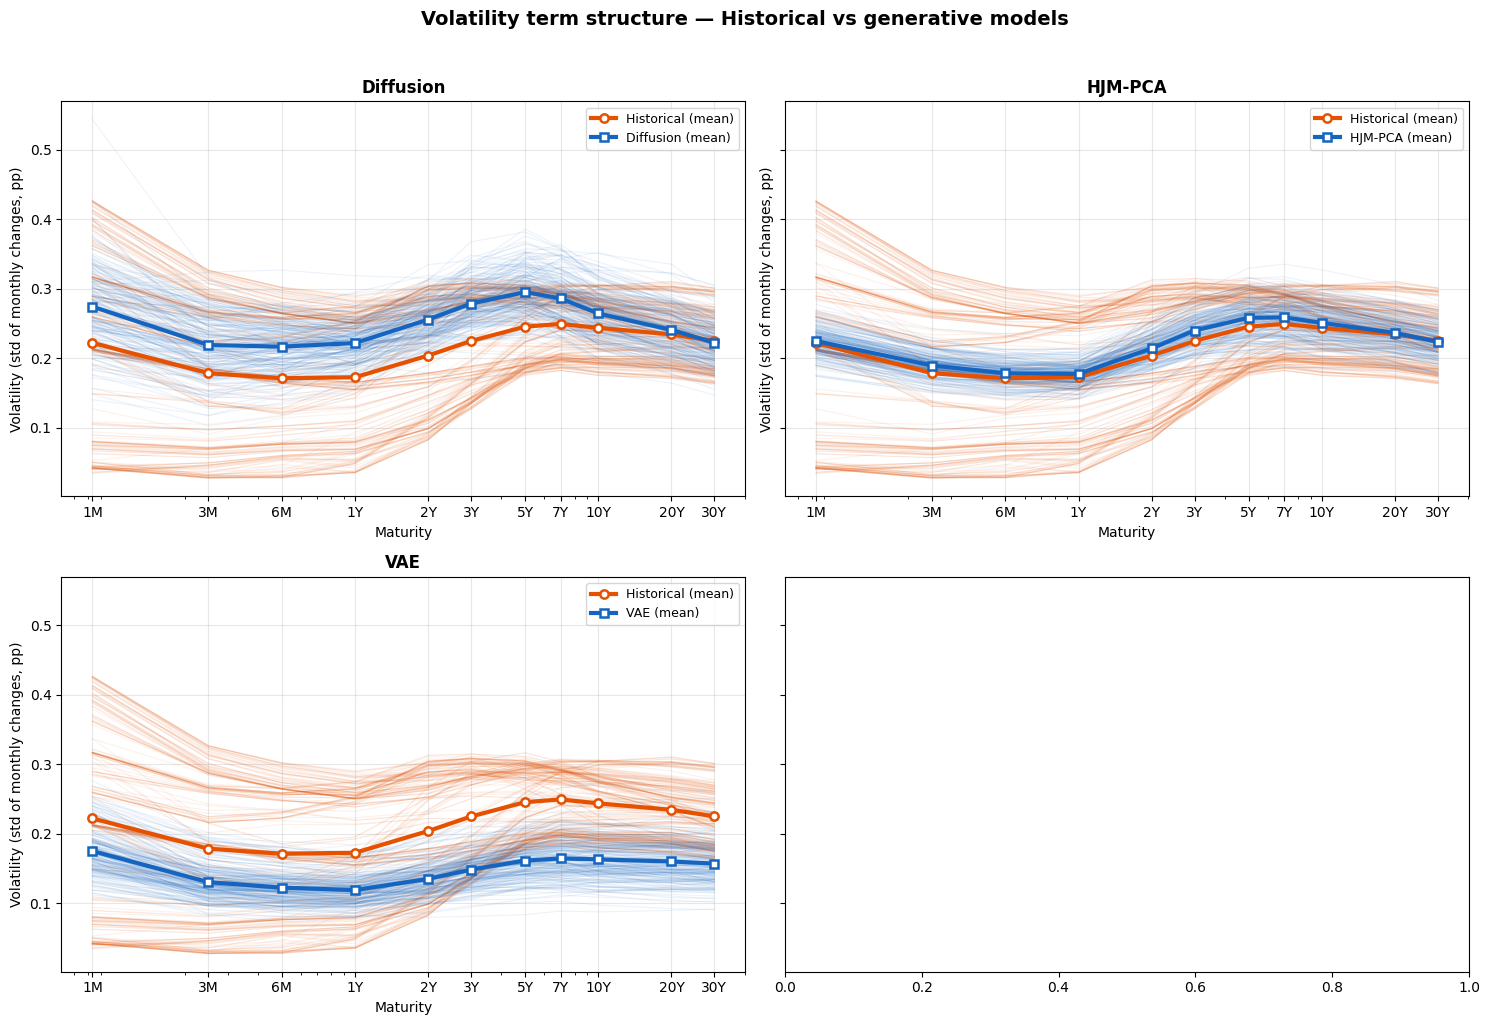

In [46]:
# ─────────────────────────────────────────────
# Volatility term structure — Historical vs every generative model
# ─────────────────────────────────────────────
# For every 60-month rolling window (historical) and every scenario (simulated)
# we compute the volatility curve: std of monthly changes per maturity.
# This is the same object, just coming from a different source — so the
# historical hist_windows and the simulated scenarios are directly comparable.
import matplotlib.pyplot as plt

SIM_YIELD_COLS = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                  "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]
MATURITY_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
MATURITY_YEARS  = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])


def vol_curve(arr):
    """
    Volatility curve per maturity: std of monthly changes.
    Accepts (T, M) for a single path, or (N, T, M) for a batch of N paths.
    Returns (M,) or (N, M).
    """
    return np.diff(arr, axis=-2).std(axis=-2)


_TENSOR_CACHE = {}

def scenario_tensor(path):
    """Load and cache scenarios as (n_scenarios, n_months, n_maturities)."""
    if path not in _TENSOR_CACHE:
        df = load_scenarios(path)
        counts = df.groupby("Scenario_ID", sort=False).size()
        if counts.nunique() != 1:
            raise ValueError(f"Scenarios in {path} do not all have the same length.")
        n_scen = len(counts)
        n_months = int(counts.iloc[0])
        values = df[SIM_YIELD_COLS].to_numpy()
        _TENSOR_CACHE[path] = values.reshape(n_scen, n_months, len(SIM_YIELD_COLS))
    return _TENSOR_CACHE[path]


# Historical volatility curves — one per 60-month rolling window
hist_vol_curves = vol_curve(hist_windows)           # (n_windows, 11)
hist_vol_mean   = hist_vol_curves.mean(axis=0)      # (11,)

# Simulated volatility curves — one per scenario, per model
sim_vol_curves = {name: vol_curve(scenario_tensor(path))
                  for name, path in MODELS.items()}


# ─────────────────────────────────────────────
# Plot: 2×2 grid, one panel per model
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
fig.suptitle("Volatility term structure — Historical vs generative models",
             fontsize=14, fontweight="bold", y=1.02)

HIST_C   = "#E65100"    # orange
SIM_C    = "#1565C0"    # blue

for ax, (name, curves) in zip(axes.flat, sim_vol_curves.items()):
    # thin lines = individual paths
    for v in hist_vol_curves:
        ax.plot(MATURITY_YEARS, v, color=HIST_C, alpha=0.08, lw=0.8)
    for v in curves:
        ax.plot(MATURITY_YEARS, v, color=SIM_C,  alpha=0.08, lw=0.8)

    # mean curves
    ax.plot(MATURITY_YEARS, hist_vol_mean, color=HIST_C, lw=3,
            marker="o", markersize=6, markerfacecolor="white",
            markeredgewidth=1.8, label="Historical (mean)")
    ax.plot(MATURITY_YEARS, curves.mean(axis=0), color=SIM_C, lw=3,
            marker="s", markersize=6, markerfacecolor="white",
            markeredgewidth=1.8, label=f"{name} (mean)")

    ax.set_xscale("log")
    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(MATURITY_LABELS)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Volatility (std of monthly changes, pp)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


In [47]:
# ─────────────────────────────────────────────
# Volatility distribution — short (1M) vs long (avg 10Y/20Y/30Y) maturities
# ─────────────────────────────────────────────
# Using 1-year and 5-year rolling windows on monthly yield changes we obtain,
# for each model and for the historical data, a distribution of volatility
# estimates. The distributions are then compared along:
#   • mean and spread (P95 - P5)
#   • Wasserstein distance (overall shape match)
#   • EVF Error   = |p_sim - p_hist| where p is the proportion of obs. above
#                  the historical 95th percentile (extreme volatility freq.)
#   • skewness and kurtosis (descriptive, tail shape)
from scipy.stats import wasserstein_distance, skew, kurtosis

SHORT_HIST = "Yield_1M"
LONG_HIST  = ["Yield_10Y", "Yield_20Y", "Yield_30Y"]
SHORT_SIM  = "Y_1M"
LONG_SIM   = ["Y_10Y", "Y_20Y", "Y_30Y"]


def rolling_vol(series, window):
    """Rolling-window std of first differences; falls back to full-series std
    when the series is too short for the requested window."""
    diffs = series.diff().dropna()
    if window <= len(diffs):
        return diffs.rolling(window).std().dropna().values
    return np.array([diffs.std()])


def hist_vol_dist(cols, window):
    series = hist_monthly[cols].mean(axis=1) if isinstance(cols, list) else hist_monthly[cols]
    return rolling_vol(series, window)


def sim_vol_dist(path, cols, window):
    tensor = scenario_tensor(path)
    idx = [SIM_YIELD_COLS.index(c) for c in cols] if isinstance(cols, list) else SIM_YIELD_COLS.index(cols)
    series = tensor[:, :, idx].mean(axis=2) if isinstance(cols, list) else tensor[:, :, idx]
    diffs = np.diff(series, axis=1)
    if window <= diffs.shape[1]:
        # rolling sample std for every scenario, vectorised
        windows = np.lib.stride_tricks.sliding_window_view(diffs, window_shape=window, axis=1)
        return windows.std(axis=-1, ddof=1).ravel()
    return diffs.std(axis=1, ddof=1)


# ─────────────────────────────────────────────
# Compute distributions for each (window, maturity-segment, model)
# ─────────────────────────────────────────────
dist_rows = []
for window_label, window in [("1Y", 12), ("5Y", 60)]:
    for seg_label, hcols, scols in [
        ("Short (1M)",                SHORT_HIST, SHORT_SIM),
        ("Long (avg 10Y/20Y/30Y)",    LONG_HIST,  LONG_SIM),
    ]:
        h = hist_vol_dist(hcols, window)
        h_p95   = np.percentile(h, 95)
        h_mean  = h.mean()
        h_spread = np.percentile(h, 95) - np.percentile(h, 5)
        p_hist  = (h > h_p95).mean()

        # historical reference row
        dist_rows.append({
            "Window":     window_label,
            "Maturity":   seg_label,
            "Model":      "Historical",
            "Mean":       h_mean,
            "Spread":     h_spread,
            "Wasserstein": 0.0,
            "EVF Error":  0.0,
            "Skew":       skew(h),
            "Kurt":       kurtosis(h),
        })

        for name, path in MODELS.items():
            s = sim_vol_dist(path, scols, window)
            p_sim = (s > h_p95).mean()
            dist_rows.append({
                "Window":     window_label,
                "Maturity":   seg_label,
                "Model":      name,
                "Mean":       s.mean(),
                "Spread":     np.percentile(s, 95) - np.percentile(s, 5),
                "Wasserstein": wasserstein_distance(h, s),
                "EVF Error":  abs(p_sim - p_hist),
                "Skew":       skew(s),
                "Kurt":       kurtosis(s),
            })

dist_df = pd.DataFrame(dist_rows)

# Pretty print grouped by window + maturity segment
print("Volatility distribution analysis — short vs long maturities")
print("=" * 90)
for (window, seg), sub in dist_df.groupby(["Window", "Maturity"], sort=False):
    print(f"\n── {window} rolling window · {seg} ──")
    print(sub.drop(columns=["Window", "Maturity"])
            .set_index("Model")
            .round(4)
            .to_string())


Volatility distribution analysis — short vs long maturities

── 1Y rolling window · Short (1M) ──
              Mean  Spread  Wasserstein  EVF Error    Skew    Kurt
Model                                                             
Historical  0.1716  0.5210       0.0000     0.0000  1.3720  1.1717
Diffusion   0.2450  0.3859       0.0805     0.0184  1.4762  3.5379
HJM-PCA     0.2228  0.1536       0.1205     0.0504  0.2552 -0.0304
VAE         0.1652  0.1916       0.0835     0.0504  0.7920  0.6861

── 1Y rolling window · Long (avg 10Y/20Y/30Y) ──
              Mean  Spread  Wasserstein  EVF Error    Skew    Kurt
Model                                                             
Historical  0.2322  0.2217       0.0000     0.0000  1.2856  1.8656
Diffusion   0.2311  0.2407       0.0085     0.0042  0.9227  1.4043
HJM-PCA     0.2323  0.1672       0.0199     0.0412  0.2682  0.1437
VAE         0.1601  0.1496       0.0722     0.0496  0.6856  0.6925

── 5Y rolling window · Short (1M) ──
          

## 4.5.1 Temporal Dynamics (ACF)

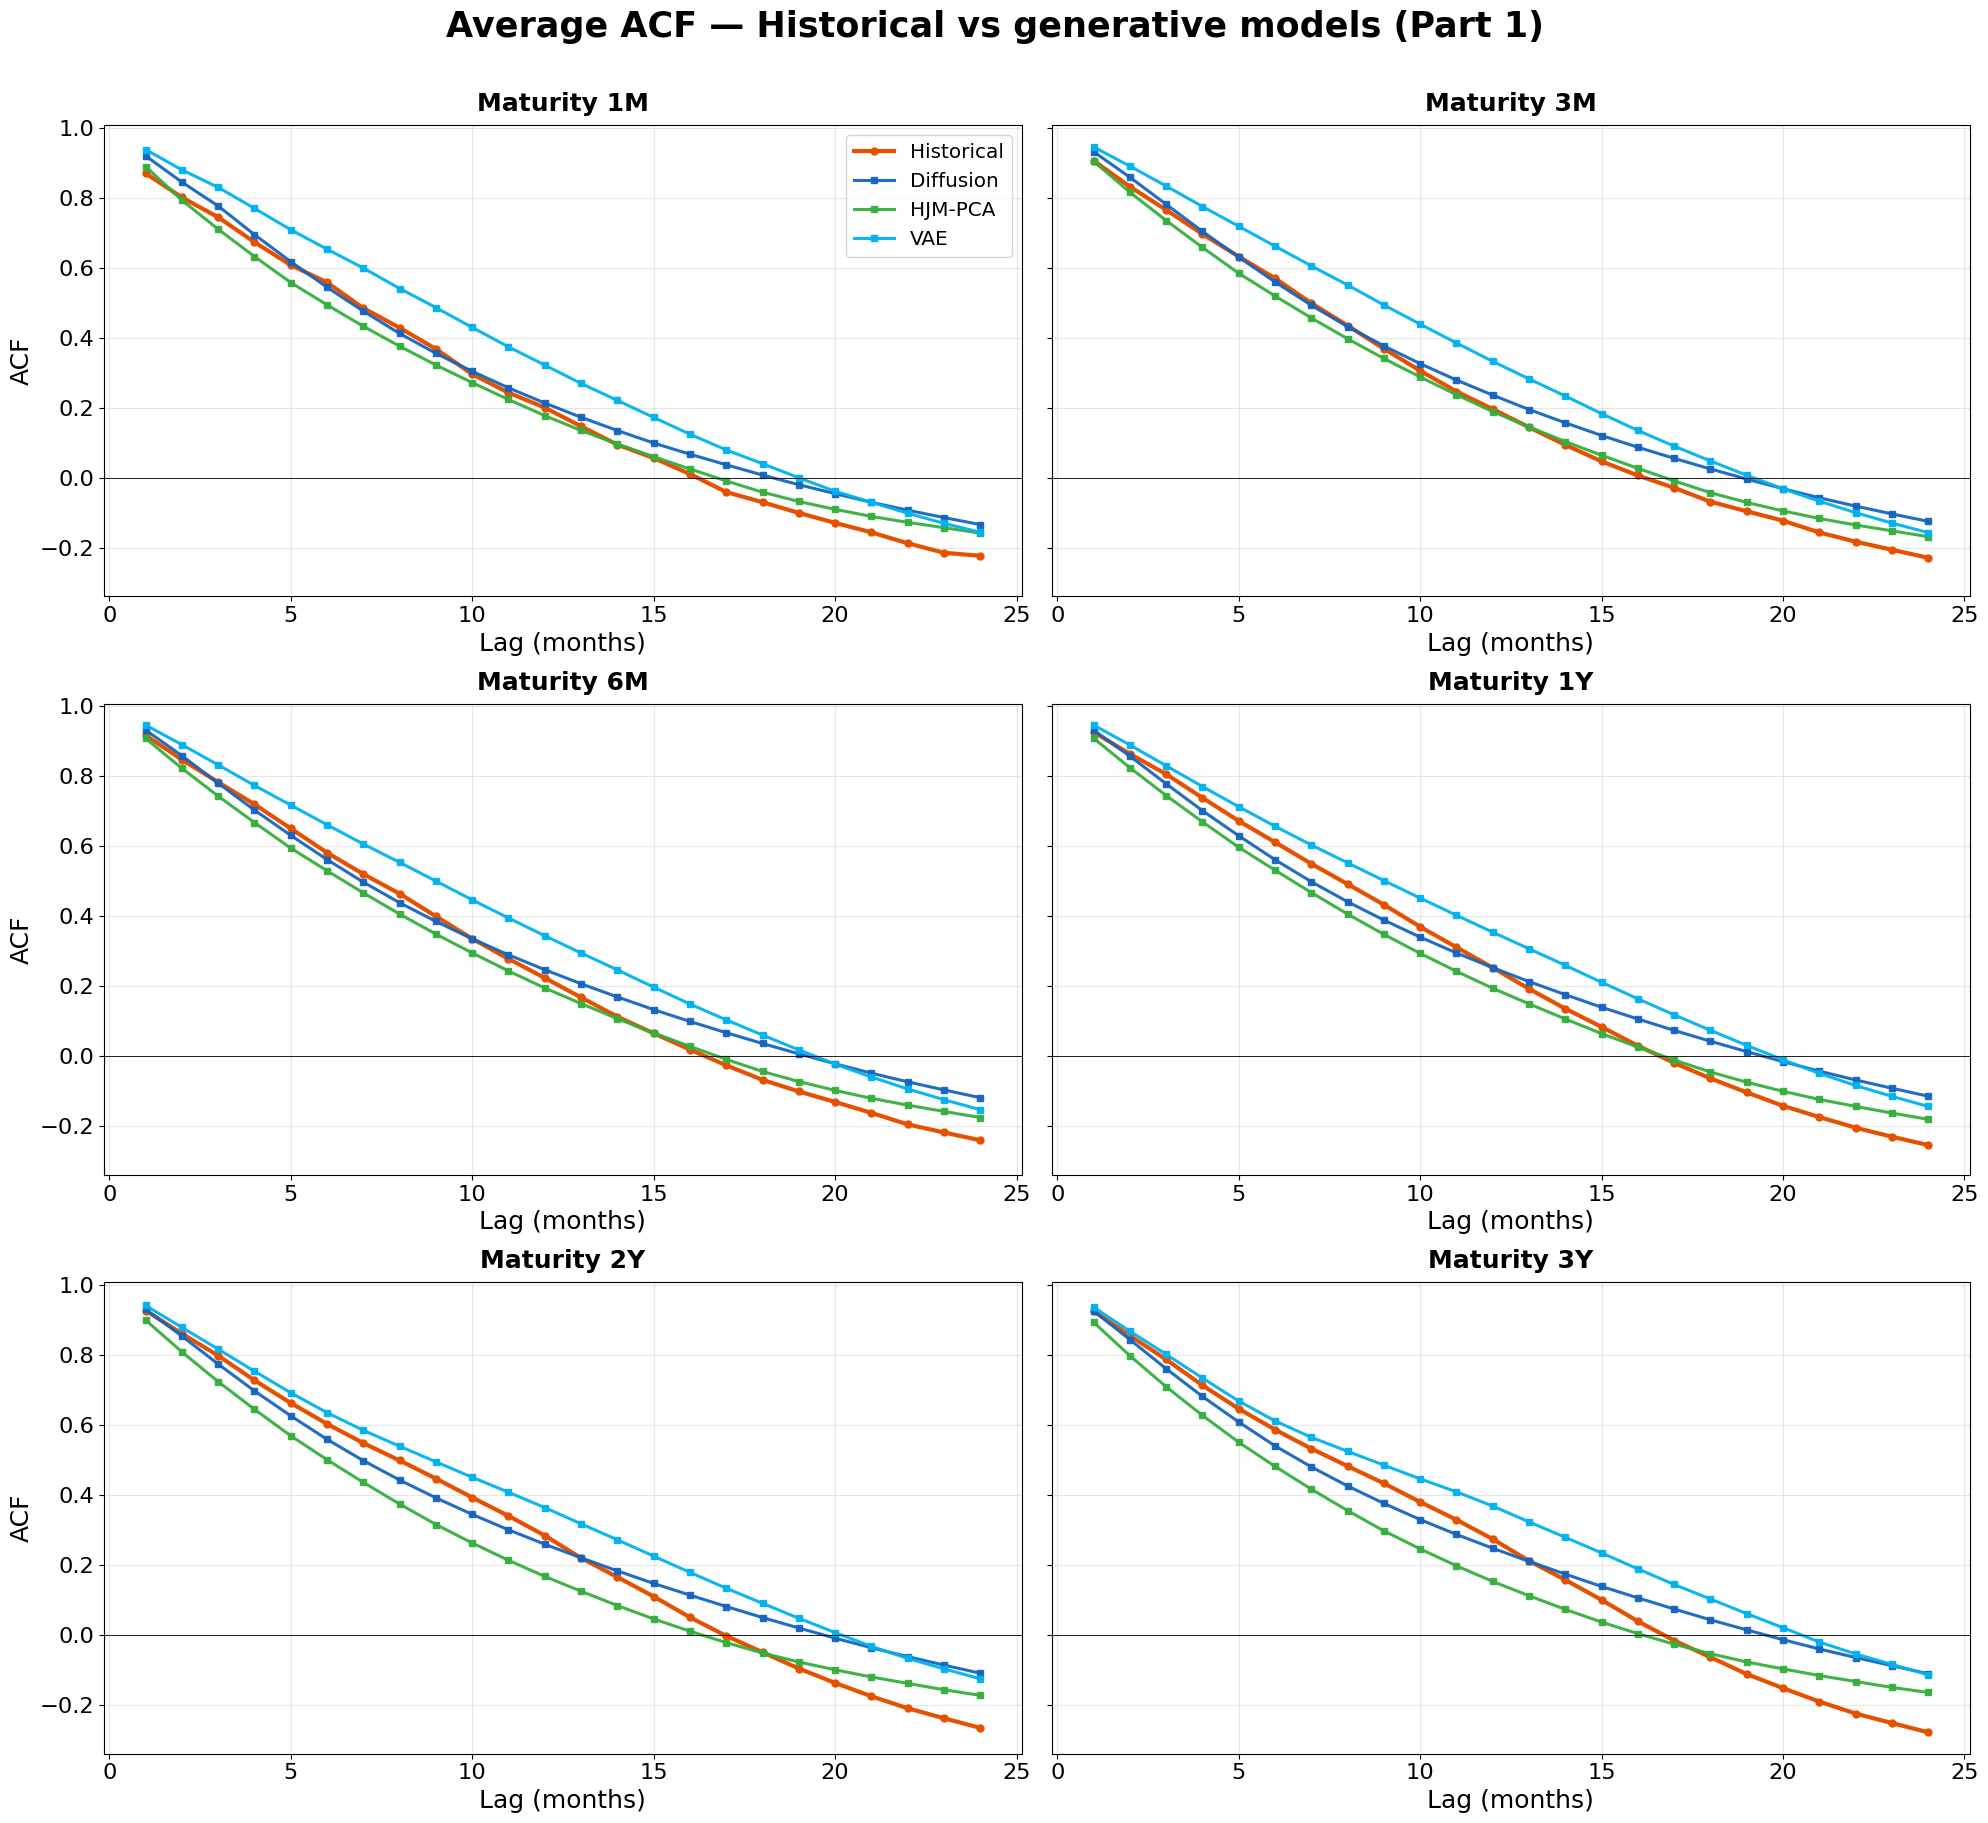

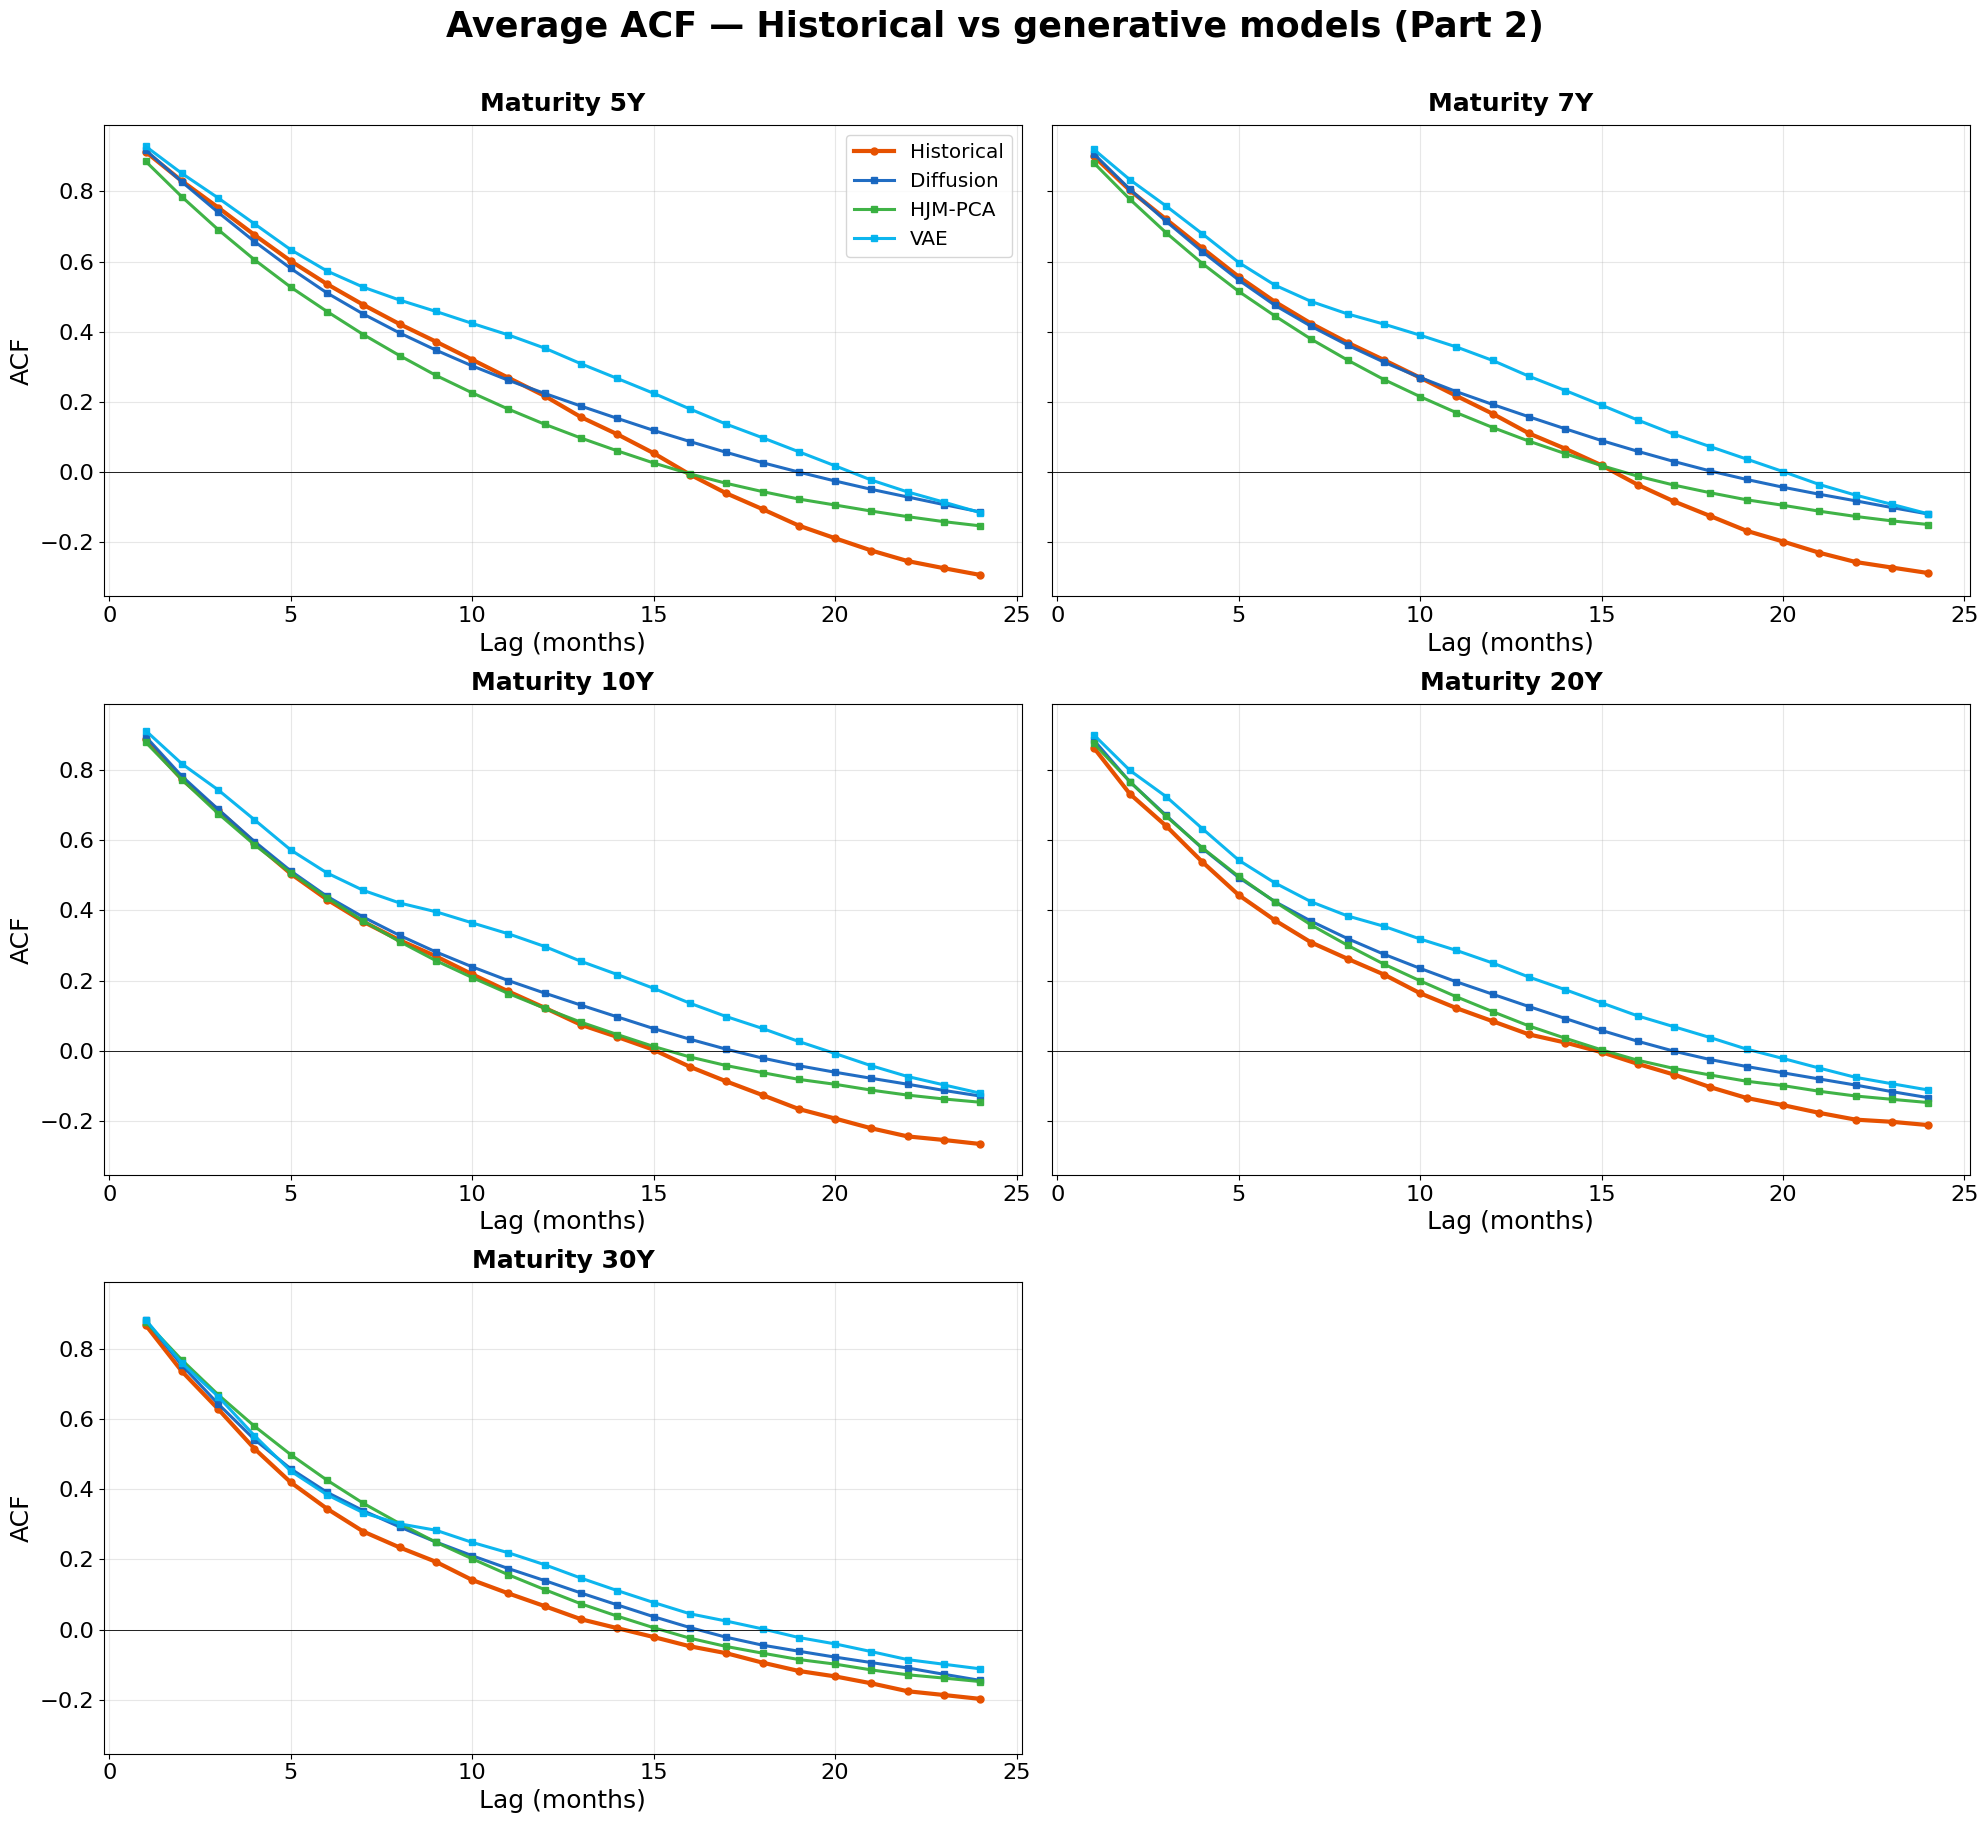

In [48]:
# ─────────────────────────────────────────────
# ACF — Historical vs every generative model
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf


# ── Global font scaling ──────────────────────────────────────────────────────
FS = 1.8

TITLE_SIZE    = 10 * FS
LABEL_SIZE    = 10 * FS
TICK_SIZE     = 9 * FS
LEGEND_SIZE   = 8 * FS
SUPTITLE_SIZE = 14 * FS

FIG_W         = 20
FIG_H_SCALE   = 6


# ─────────────────────────────────────────────
# ACF setup
# ─────────────────────────────────────────────

N_LAGS = 24

LAGS = np.arange(1, N_LAGS + 1)


def acf_batch(paths, nlags=N_LAGS):
    """
    paths : (N, T, M)
    Returns : (N, M, nlags)
    """

    N, T, M = paths.shape

    out = np.zeros((N, M, nlags))

    for n in range(N):

        for m in range(M):

            s = paths[n, :, m]

            if np.std(s) < 1e-10:
                continue

            out[n, m] = acf(
                s,
                nlags=nlags,
                fft=True
            )[1:]

    return out


# Historical ACF
hist_acf = acf_batch(hist_windows)

hist_acf_mean = hist_acf.mean(axis=0)


# Simulated ACF
sim_acf = {
    name: acf_batch(scenario_tensor(path))
    for name, path in MODELS.items()
}

sim_acf_mean = {
    name: a.mean(axis=0)
    for name, a in sim_acf.items()
}


# ─────────────────────────────────────────────
# Plot settings
# ─────────────────────────────────────────────
MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#35AF3D",
    "CANN":      "#A63BC6",
    "VAE":       "#00B2EE",
}

HIST_COLOR = "#E65100"


# ─────────────────────────────────────────────
# Helper plotting function
# ─────────────────────────────────────────────

def plot_acf_group(indices, figure_title):

    n_mat = len(indices)

    ncols = 2

    nrows = int(np.ceil(n_mat / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(FIG_W, nrows * FIG_H_SCALE),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        figure_title,
        fontsize=SUPTITLE_SIZE,
        fontweight="bold",
        y=1.01
    )

    for plot_idx, mat_idx in enumerate(indices):

        ax = axes[plot_idx]

        label = MATURITY_LABELS[mat_idx]

        # Historical
        ax.plot(
            LAGS,
            hist_acf_mean[mat_idx],
            color=HIST_COLOR,
            lw=3,
            marker="o",
            markersize=5,
            label="Historical"
        )

        # Models
        for name, mat_acf in sim_acf_mean.items():

            ax.plot(
                LAGS,
                mat_acf[mat_idx],
                color=MODEL_COLORS[name],
                lw=2.2,
                alpha=0.95,
                marker="s",
                markersize=4,
                label=name
            )

        ax.axhline(
            0,
            color="black",
            lw=0.6
        )

        ax.set_title(
            f"Maturity {label}",
            fontsize=TITLE_SIZE,
            fontweight="bold",
            pad=10
        )

        # X-axis label on every subplot
        ax.set_xlabel(
            "Lag (months)",
            fontsize=LABEL_SIZE
        )

        ax.tick_params(labelbottom=True)

        # Only left column gets y-axis labels
        if plot_idx % ncols == 0:

            ax.set_ylabel(
                "ACF",
                fontsize=LABEL_SIZE
            )

        else:

            ax.tick_params(labelleft=False)

        ax.tick_params(
            axis="both",
            labelsize=TICK_SIZE
        )

        ax.grid(alpha=0.3)

        if plot_idx == 0:

            ax.legend(
                fontsize=LEGEND_SIZE,
                loc="upper right"
            )

    # Hide unused subplot
    for ax in axes[n_mat:]:

        ax.set_visible(False)

    plt.tight_layout()

    plt.show()


# ─────────────────────────────────────────────
# First 6 maturities
# ─────────────────────────────────────────────

plot_acf_group(
    indices=[0, 1, 2, 3, 4, 5],
    figure_title="Average ACF — Historical vs generative models (Part 1)"
)


# ─────────────────────────────────────────────
# Last 5 maturities
# ─────────────────────────────────────────────

plot_acf_group(
    indices=[6, 7, 8, 9, 10],
    figure_title="Average ACF — Historical vs generative models (Part 2)"
)

### Global deviation score
The global score averages the per-maturity score over all 11 maturities within each scenario, then aggregates over the 200 scenarios. A single number summarises how well each model reproduces the persistence structure across the yield curve.

In [49]:
# ─────────────────────────────────────────────
# Per-maturity deviation score  S^mean_m
# ─────────────────────────────────────────────
# S^mean = (1/K) Σ_k (ρ̄_k − ρ_k^hist)²
# ρ̄_k   = mean simulated ACF across all scenarios at lag k
# ρ_k^hist = average historical ACF at lag k
# K = 24 (two-year horizon)

per_mat_rows = {}
for name, a in sim_acf.items():
    # a shape: (n_scen, 11, K)
    rho_bar = a.mean(axis=0)                              # (11, K) — mean across scenarios
    S_m     = ((rho_bar - hist_acf_mean) ** 2).mean(axis=1)  # (11,) — mean over K lags
    per_mat_rows[name] = S_m

acf_per_mat_df = pd.DataFrame(per_mat_rows, index=MATURITY_LABELS)
acf_per_mat_df.index.name = "Maturity"

acf_per_mat_df.loc["Global"] = acf_per_mat_df.mean()

print("Per-maturity ACF deviation score (×10⁻³)  S^mean  — lower is better")
print("=" * 70)
print((acf_per_mat_df * 1000).round(5).to_string())

Per-maturity ACF deviation score (×10⁻³)  S^mean  — lower is better
          Diffusion  HJM-PCA       VAE
Maturity                              
1M          3.09833  1.61161  11.02408
3M          4.06833  1.06773  11.41084
6M          4.97640  1.63023  10.39314
1Y          6.24082  3.33040   9.77086
2Y          6.62394  7.24351   9.72370
3Y          7.65085  8.32926  13.36536
5Y          9.57875  6.73423  20.38158
7Y          8.80703  4.83508  20.67381
10Y         6.39135  3.23930  21.27355
20Y         4.78984  1.73044  16.02745
30Y         2.97382  2.45150   7.09686
Global      5.92722  3.83666  13.74011


## 4.5.4 Yield Curve Shape — Nelson–Siegel

Fit the Nelson–Siegel decomposition (fixed λ = 0.0609, Diebold-Li convention) to every yield curve in the historical dataset and in all four generative models. Compare the resulting β-factor distributions visually and via Wasserstein distance.

Historical betas : (290, 3)
Diffusion   : 12,000 curves
HJM-PCA     : 12,000 curves
VAE         : 12,000 curves


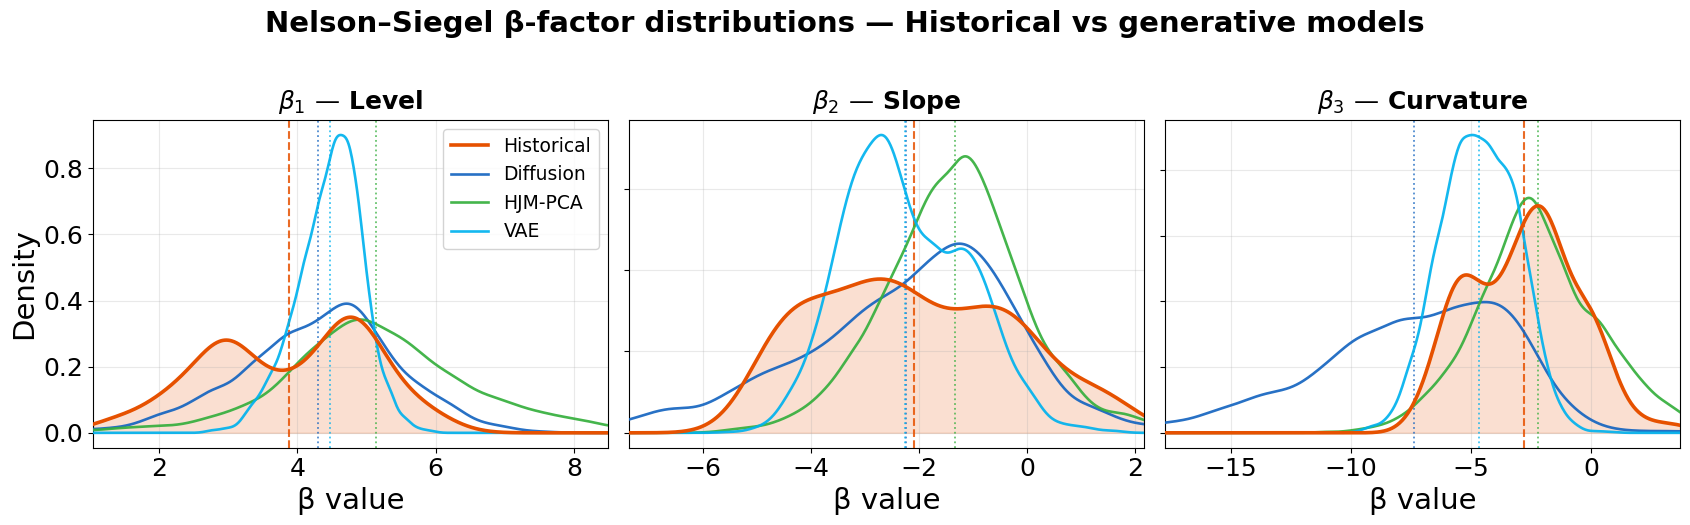


Dashed vertical lines = distribution means.


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.5.4  Yield Curve Shape — Nelson–Siegel
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")


# ── Global font scaling ──────────────────────────────────────────────────────
FS = 1.5

TITLE_SIZE     = 12 * FS
LABEL_SIZE     = 14 * FS
TICK_SIZE      = 12 * FS
LEGEND_SIZE    = 9 * FS
SUPTITLE_SIZE  = 14 * FS

FIG_W          = 17
FIG_H          = 5


# ── Nelson–Siegel helpers ────────────────────────────────────────────────────
NS_LAMBDA     = 0.0609

MATS_MONTHS   = np.array([
    1/12, 3/12, 6/12, 1, 2, 3,
    5, 7, 10, 20, 30
]) * 12

SIM_YLD_COLS  = [
    "Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
    "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"
]

HIST_YLD_COLS = [
    "Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
    "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y",
    "Yield_20Y","Yield_30Y"
]


def _ns_matrix(mats, lam):

    lt = lam * mats

    return np.column_stack([
        np.ones_like(lt),
        (1 - np.exp(-lt)) / lt,
        (1 - np.exp(-lt)) / lt - np.exp(-lt)
    ])


_NS_X = _ns_matrix(MATS_MONTHS, NS_LAMBDA)


def fit_betas(yield_matrix):
    """
    OLS Nelson–Siegel fit for every row.
    """

    betas, _, _, _ = np.linalg.lstsq(
        _NS_X,
        yield_matrix.T,
        rcond=None
    )

    return betas.T


# ── Historical betas ─────────────────────────────────────────────────────────
hist_betas_shape = fit_betas(
    hist_monthly[HIST_YLD_COLS].values
)

print(
    f"Historical betas : {hist_betas_shape.shape}"
)


# ── Simulated betas ──────────────────────────────────────────────────────────
sim_betas_shape = {}

for name, path in MODELS.items():

    df = load_scenarios(path)

    yields = df[SIM_YLD_COLS].values

    sim_betas_shape[name] = fit_betas(yields)

    print(
        f"{name:12s}: "
        f"{sim_betas_shape[name].shape[0]:6,} curves"
    )


# ── Colours ──────────────────────────────────────────────────────────────────
_MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#35AF3D",
    "VAE":       "#00B2EE",
}

_HIST_COLOR = "#E65100"


# ── Plot ─────────────────────────────────────────────────────────────────────
BETA_LABELS = [
    r"$\beta_1$ — Level",
    r"$\beta_2$ — Slope",
    r"$\beta_3$ — Curvature",
]

N_GRID = 600

fig, axes = plt.subplots(
    1,
    3,
    figsize=(FIG_W, FIG_H)
)

fig.suptitle(
    "Nelson–Siegel β-factor distributions — Historical vs generative models",
    fontsize=SUPTITLE_SIZE,
    fontweight="bold",
    y=1.04,
)

for j, (ax, blabel) in enumerate(zip(axes, BETA_LABELS)):

    # Shared x-range
    all_vals = np.concatenate(
        [hist_betas_shape[:, j]] +
        [b[:, j] for b in sim_betas_shape.values()]
    )

    lo = np.percentile(all_vals, 0.5)
    hi = np.percentile(all_vals, 99.5)

    x_grid = np.linspace(lo, hi, N_GRID)

    # Historical
    h = hist_betas_shape[:, j]

    kde_h = gaussian_kde(
        h,
        bw_method="scott"
    )

    ax.fill_between(
        x_grid,
        kde_h(x_grid),
        alpha=0.18,
        color=_HIST_COLOR
    )

    ax.plot(
        x_grid,
        kde_h(x_grid),
        lw=2.6,
        color=_HIST_COLOR,
        label="Historical",
        zorder=6
    )

    ax.axvline(
        h.mean(),
        color=_HIST_COLOR,
        ls="--",
        lw=1.5,
        alpha=0.85
    )

    # Models
    for name, betas in sim_betas_shape.items():

        s = betas[:, j]

        kde_s = gaussian_kde(
            s,
            bw_method="scott"
        )

        col = _MODEL_COLORS[name]

        ax.plot(
            x_grid,
            kde_s(x_grid),
            lw=1.9,
            color=col,
            label=name,
            alpha=0.92,
            zorder=5
        )

        ax.axvline(
            s.mean(),
            color=col,
            ls=":",
            lw=1.3,
            alpha=0.75
        )

    ax.set_xlim(lo, hi)

    ax.set_title(
        blabel,
        fontsize=TITLE_SIZE,
        fontweight="bold",
        pad=8
    )

    ax.set_xlabel(
        "β value",
        fontsize=LABEL_SIZE
    )

    # Only left plot gets y-label
    if j == 0:

        ax.set_ylabel(
            "Density",
            fontsize=LABEL_SIZE
        )

    else:

        ax.tick_params(labelleft=False)

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.grid(alpha=0.28)

    if j == 0:

        ax.legend(
            fontsize=LEGEND_SIZE,
            loc="upper right",
            framealpha=0.85
        )

plt.tight_layout()

plt.show()

print("\nDashed vertical lines = distribution means.")

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# Wasserstein Distance Summary Table — Nelson–Siegel Shape
# ─────────────────────────────────────────────────────────────────────────────
# For each model and each β-factor compute the Wasserstein-1 distance between
# the simulated distribution and the historical distribution.
# A lower value means the model better reproduces the historical yield curve
# shape distribution for that factor.
# ─────────────────────────────────────────────────────────────────────────────

from scipy.stats import wasserstein_distance
import pandas as pd

factor_names = ["Level (β₁)", "Slope (β₂)", "Curvature (β₃)"]

rows = []
for name, betas in sim_betas_shape.items():
    row = {"Model": name}
    for j, fname in enumerate(factor_names):
        row[fname] = wasserstein_distance(
            hist_betas_shape[:, j], betas[:, j]
        )
    rows.append(row)

wass_df = (
    pd.DataFrame(rows)
    .set_index("Model")
    .assign(**{"Total (sum)": lambda df: df.sum(axis=1)})
    .sort_values("Total (sum)")
)

print("=" * 65)
print("   Wasserstein Distances — Nelson–Siegel β Distributions")
print("   (Historical vs simulated;  lower = better)")
print("=" * 65)
print(wass_df.round(4).to_string())
print("=" * 65)
print()
# Highlight best model per factor
for col in factor_names:
    best = wass_df[col].idxmin()
    print(f"  Best {col:20s}: {best}  (W = {wass_df.loc[best, col]:.4f})")
print(f"  Best overall (total)         : {wass_df['Total (sum)'].idxmin()}")


   Wasserstein Distances — Nelson–Siegel β Distributions
   (Historical vs simulated;  lower = better)
           Level (β₁)  Slope (β₂)  Curvature (β₃)  Total (sum)
Model                                                         
HJM-PCA        1.2614      0.7859          0.6472       2.6946
VAE            0.7075      0.6007          1.8809       3.1891
Diffusion      0.4308      0.3774          4.6060       5.4142

  Best Level (β₁)          : Diffusion  (W = 0.4308)
  Best Slope (β₂)          : Diffusion  (W = 0.3774)
  Best Curvature (β₃)      : HJM-PCA  (W = 0.6472)
  Best overall (total)         : HJM-PCA


## 4.5.3 Cross-Maturity Correlation

For each model, compute the average cross-maturity correlation matrix (60-month window per scenario / rolling window for historical) and plot: **Historical | Model | |Difference|** stacked one model per row. The L1 norm summarises the total absolute deviation.

Historical: 231 rolling windows
Diffusion   : 200 scenarios
HJM-PCA     : 200 scenarios
VAE         : 200 scenarios


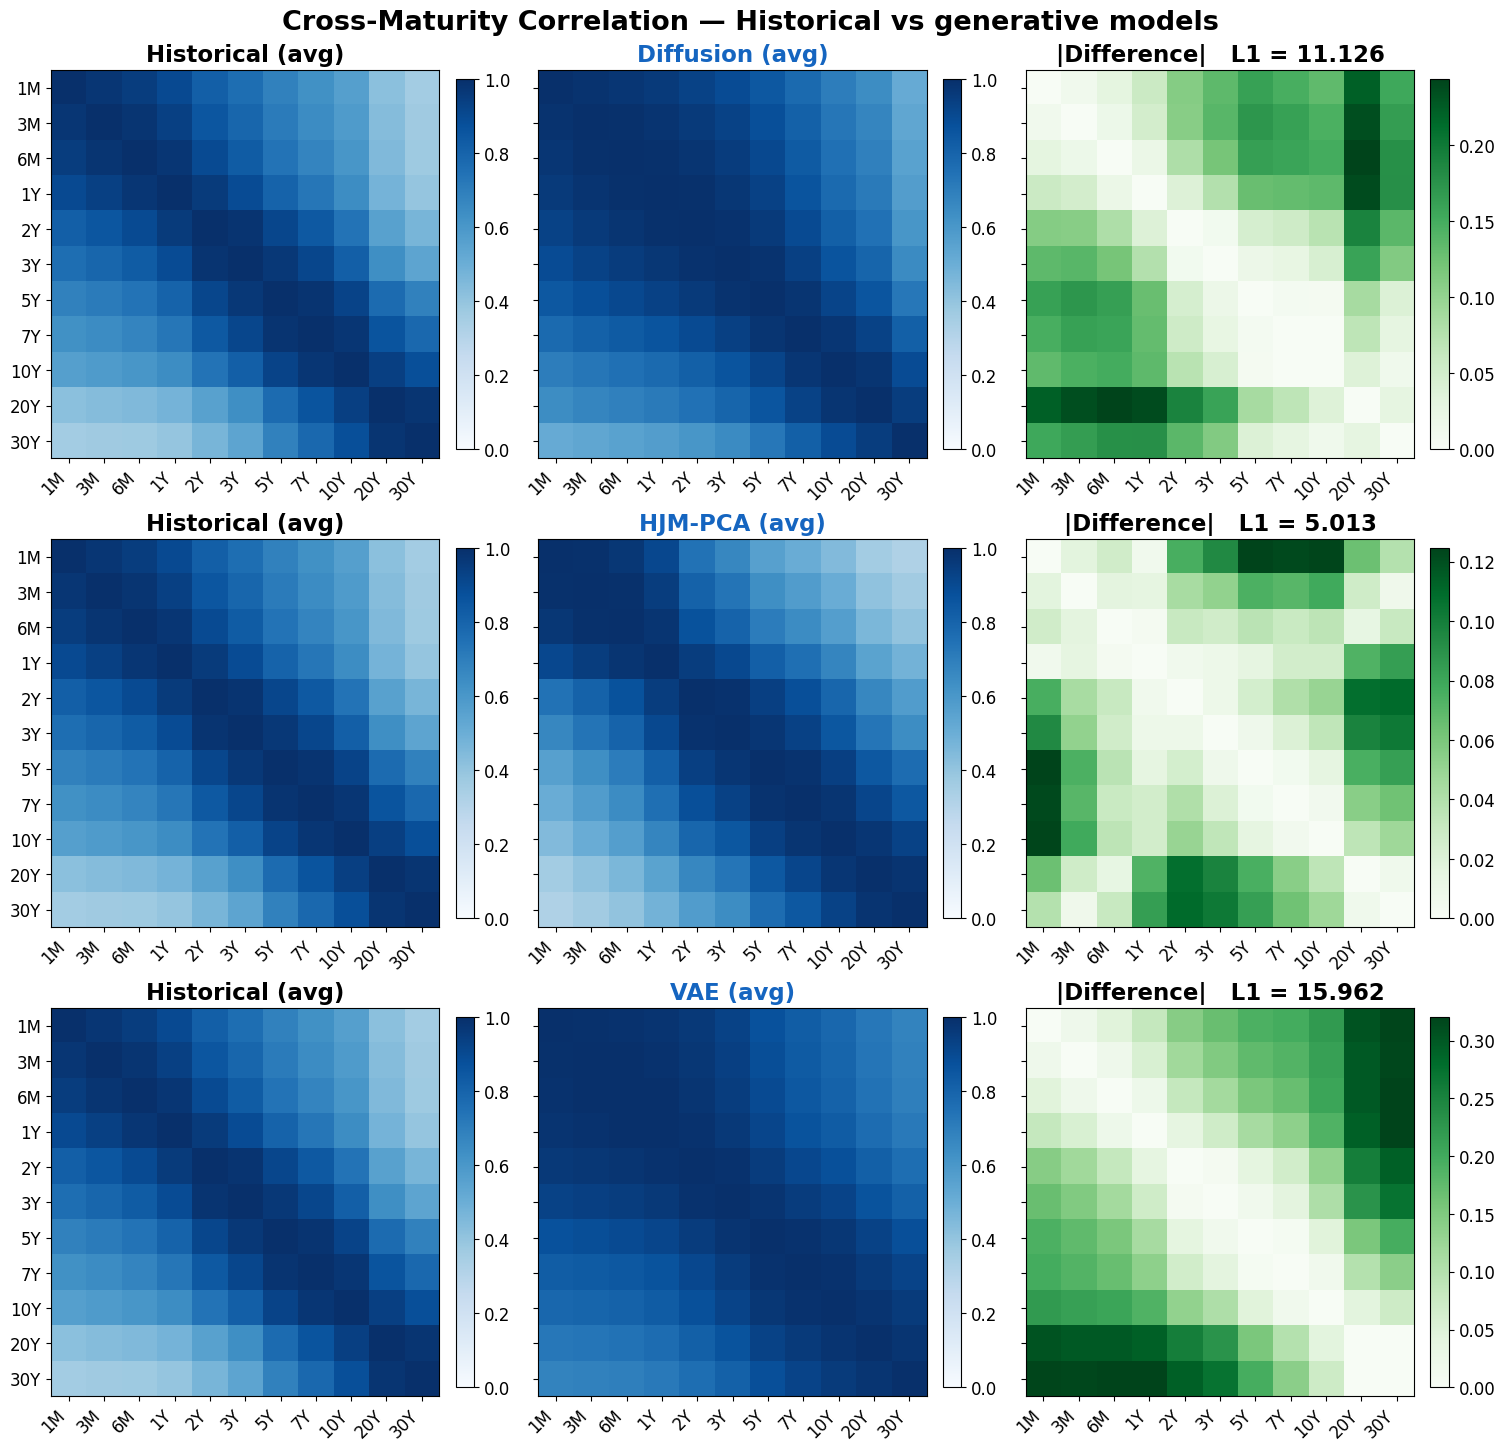


L1 norms: {'Diffusion': np.float64(11.1264), 'HJM-PCA': np.float64(5.013), 'VAE': np.float64(15.9615)}


In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.5.3  Cross-Maturity Correlation — all models, one row each
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


# ── Global font scaling ──────────────────────────────────────────────────────
FS = 1.5

TITLE_SIZE      = 11 * FS
LABEL_SIZE      = 10 * FS
TICK_SIZE       = 8 * FS
SUPTITLE_SIZE   = 13 * FS
COLORBAR_SIZE   = 8 * FS

FIG_W           = 15
FIG_H           = 4.8


# ── Labels ───────────────────────────────────────────────────────────────────
YIELD_COLS_SIM  = [
    "Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
    "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"
]

YIELD_COLS_HIST = [
    "Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
    "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y",
    "Yield_20Y","Yield_30Y"
]

MAT_LABELS = [
    "1M","3M","6M","1Y","2Y",
    "3Y","5Y","7Y","10Y","20Y","30Y"
]


# ── Helper functions ─────────────────────────────────────────────────────────
def cross_corr_matrix(X):

    T = X.shape[0]

    mean = X.mean(axis=0)

    cov = (X.T @ X) / T - np.outer(mean, mean)

    std = np.sqrt(np.diag(cov))

    denom = np.outer(std, std)

    return np.where(
        denom > 0,
        cov / denom,
        0.0
    )


def mean_corr(windows_or_scenarios):

    return np.mean(
        [cross_corr_matrix(w) for w in windows_or_scenarios],
        axis=0
    )


# ── Historical correlation ───────────────────────────────────────────────────
hist_corr = mean_corr(hist_windows)

print(
    f"Historical: {len(hist_windows)} rolling windows"
)


# ── Simulated correlations ───────────────────────────────────────────────────
sim_corrs = {}

for name, path in MODELS.items():

    tensor = scenario_tensor(path)

    sim_corrs[name] = mean_corr(tensor)

    print(
        f"{name:12s}: {tensor.shape[0]} scenarios"
    )


# ── Plot ─────────────────────────────────────────────────────────────────────
n_models = len(MODELS)

fig, axes = plt.subplots(
    n_models,
    3,
    figsize=(FIG_W, FIG_H * n_models),
    constrained_layout=True
)

fig.suptitle(
    "Cross-Maturity Correlation — Historical vs generative models",
    fontsize=SUPTITLE_SIZE,
    fontweight="bold"
)

_MODEL_COLORS_LABEL = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#1565C0",
    "VAE":       "#1565C0",
}




l1_norms = {}

for row_idx, (name, sim_corr) in enumerate(sim_corrs.items()):

    diff = np.abs(hist_corr - sim_corr)

    l1 = diff.sum()

    l1_norms[name] = l1

    ax_hist, ax_sim, ax_diff = axes[row_idx]

    color = _MODEL_COLORS_LABEL[name]

    # ── Historical panel ────────────────────────────────────────────────
    im0 = ax_hist.imshow(
        hist_corr,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    ax_hist.set_title(
        "Historical (avg)",
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    cbar0 = plt.colorbar(
        im0,
        ax=ax_hist,
        fraction=0.046,
        pad=0.04
    )

    cbar0.ax.tick_params(
        labelsize=COLORBAR_SIZE
    )

    # ── Simulated panel ─────────────────────────────────────────────────
    im1 = ax_sim.imshow(
        sim_corr,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    ax_sim.set_title(
        f"{name} (avg)",
        fontsize=TITLE_SIZE,
        color=color,
        fontweight="bold"
    )

    cbar1 = plt.colorbar(
        im1,
        ax=ax_sim,
        fraction=0.046,
        pad=0.04
    )

    cbar1.ax.tick_params(
        labelsize=COLORBAR_SIZE
    )

    # ── Difference panel ────────────────────────────────────────────────
    im2 = ax_diff.imshow(
        diff,
        cmap="Greens",
        vmin=0
    )

    ax_diff.set_title(
        f"|Difference|   L1 = {l1:.3f}",
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    cbar2 = plt.colorbar(
        im2,
        ax=ax_diff,
        fraction=0.046,
        pad=0.04
    )

    cbar2.ax.tick_params(
        labelsize=COLORBAR_SIZE
    )

    # ── Axis labels ─────────────────────────────────────────────────────
    for col_idx, ax in enumerate((ax_hist, ax_sim, ax_diff)):

        ax.set_xticks(range(len(MAT_LABELS)))

        ax.set_yticks(range(len(MAT_LABELS)))

        ax.set_xticklabels(
            MAT_LABELS,
            rotation=45,
            ha="right",
            fontsize=TICK_SIZE
        )

        # Only left column gets y-axis labels
        if col_idx == 0:

            ax.set_yticklabels(
                MAT_LABELS,
                fontsize=TICK_SIZE
            )

        else:

            ax.tick_params(labelleft=False)

plt.show()

print(
    "\nL1 norms:",
    {k: round(v, 4) for k, v in l1_norms.items()}
)

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# L1 Norm Summary Table — Cross-Maturity Correlation
# ─────────────────────────────────────────────────────────────────────────────
# l1_norms dict was populated in the plot cell above.

import pandas as pd

summary = (
    pd.DataFrame.from_dict(l1_norms, orient="index", columns=["L1 Norm"])
    .sort_values("L1 Norm")
    .rename_axis("Model")
)

print("=" * 45)
print("  Cross-Maturity Correlation — L1 Norm")
print("  (Σ_i Σ_j |ρ_hist^{ij} − ρ_sim^{ij}|)")
print("  Lower = better match to historical")
print("=" * 45)
print(summary.round(4).to_string())
print("=" * 45)
print(f"\n  Best model: {summary['L1 Norm'].idxmin()}  "
      f"(L1 = {summary['L1 Norm'].min():.4f})")


  Cross-Maturity Correlation — L1 Norm
  (Σ_i Σ_j |ρ_hist^{ij} − ρ_sim^{ij}|)
  Lower = better match to historical
           L1 Norm
Model             
HJM-PCA     5.0130
Diffusion  11.1264
VAE        15.9615

  Best model: HJM-PCA  (L1 = 5.0130)


## 4.7 Tail Behaviour & Extreme Scenarios

For each Nelson–Siegel factor (β₁ Level, β₂ Slope, β₃ Curvature) every generated observation is classified into three tiers:

- **Normal**: within the historical 5th–95th percentile range
- **Tail**: outside the 5th/95th percentile but within the historical min/max — extreme but plausible
- **Unrealistic**: beyond the historical min/max — a configuration never seen in the data

This is done for both **shape-based** analysis (β-factor levels) and **dynamic** analysis (month-to-month first differences Δβ). Historical serves as the benchmark: ~90% normal, ~10% tail, 0% unrealistic by construction.

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.7  Tail Behaviour — compute three-tier proportions for all models
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

HIST_YLD_COLS = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
                 "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]
SIM_YLD_COLS  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                 "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]
FACTOR_NAMES  = [r"$\beta_1$ Level", r"$\beta_2$ Slope", r"$\beta_3$ Curvature"]

# ── NS helpers (reuse same setup as shape section) ───────────────────────────
NS_LAMBDA   = 0.0609
MATS_MONTHS = np.array([1/12,3/12,6/12,1,2,3,5,7,10,20,30]) * 12

def _ns_X(mats, lam):
    lt = lam * mats
    return np.column_stack([np.ones_like(lt),
                            (1-np.exp(-lt))/lt,
                            (1-np.exp(-lt))/lt - np.exp(-lt)])

_NS_X = _ns_X(MATS_MONTHS, NS_LAMBDA)

def fit_betas(Y):
    betas, _, _, _ = np.linalg.lstsq(_NS_X, np.atleast_2d(Y).T, rcond=None)
    return betas.T

# ── Historical betas (monthly time series, not rolling windows) ───────────────
hist_betas_ts  = fit_betas(hist_monthly[HIST_YLD_COLS].values)   # (n_months, 3)
hist_diff_ts   = np.diff(hist_betas_ts, axis=0)                  # (n_months-1, 3)

# ── Thresholds from historical ────────────────────────────────────────────────
shape_tail_lo = np.percentile(hist_betas_ts,  5,  axis=0)   # (3,)
shape_tail_hi = np.percentile(hist_betas_ts,  95, axis=0)
shape_min     = hist_betas_ts.min(axis=0)
shape_max     = hist_betas_ts.max(axis=0)

dyn_tail_lo   = np.percentile(hist_diff_ts,   5,  axis=0)   # (3,)
dyn_tail_hi   = np.percentile(hist_diff_ts,   95, axis=0)
dyn_min       = hist_diff_ts.min(axis=0)
dyn_max       = hist_diff_ts.max(axis=0)

print("Shape thresholds (P5 / P95 / min / max) per factor:")
for i, n in enumerate(["β1","β2","β3"]):
    print(f"  {n}: tail=[{shape_tail_lo[i]:.3f}, {shape_tail_hi[i]:.3f}]  "
          f"min/max=[{shape_min[i]:.3f}, {shape_max[i]:.3f}]")

print("\nDynamic thresholds (P5 / P95 / min / max) per factor:")
for i, n in enumerate(["Δβ1","Δβ2","Δβ3"]):
    print(f"  {n}: tail=[{dyn_tail_lo[i]:.3f}, {dyn_tail_hi[i]:.3f}]  "
          f"min/max=[{dyn_min[i]:.3f}, {dyn_max[i]:.3f}]")

# ── Classification helper ─────────────────────────────────────────────────────
def three_tiers(vals, t_lo, t_hi, v_min, v_max):
    """Classify a 1-D array into (normal, tail, unrealistic) proportions."""
    n = len(vals)
    normal      = ((vals >= t_lo) & (vals <= t_hi)).sum() / n
    tail        = (((vals >= v_min) & (vals < t_lo)) |
                   ((vals > t_hi)  & (vals <= v_max))).sum() / n
    unrealistic = ((vals < v_min) | (vals > v_max)).sum() / n
    return normal, tail, unrealistic

# ── Compute proportions for all datasets ────────────────────────────────────
def get_shape_props(betas_flat):
    """betas_flat : (N, 3) → dict factor → (normal, tail, unrealistic)"""
    return {i: three_tiers(betas_flat[:,i],
                           shape_tail_lo[i], shape_tail_hi[i],
                           shape_min[i], shape_max[i])
            for i in range(3)}

def get_dyn_props(betas_by_scenario):
    """betas_by_scenario : (n_scen, 60, 3) — diffs computed within each scenario"""
    diffs = np.diff(betas_by_scenario, axis=1).reshape(-1, 3)   # (n_scen*59, 3)
    return {i: three_tiers(diffs[:,i],
                           dyn_tail_lo[i], dyn_tail_hi[i],
                           dyn_min[i], dyn_max[i])
            for i in range(3)}

# Historical (reference)
tail_results = {
    "Historical": {
        "shape": get_shape_props(hist_betas_ts),
        "dyn":   get_dyn_props(hist_betas_ts[np.newaxis, :, :]),   # treat as 1 scenario
    }
}

# All four models
for name, path in MODELS.items():
    tensor = scenario_tensor(path)                                  # (200, 60, 11)
    betas_flat = fit_betas(tensor.reshape(-1, 11))                  # (12000, 3)
    betas_sc   = np.stack([fit_betas(tensor[s]) for s in range(200)])  # (200, 60, 3)
    tail_results[name] = {
        "shape": get_shape_props(betas_flat),
        "dyn":   get_dyn_props(betas_sc),
    }
    print(f"  {name:12s} done.")

print("\nAll proportions computed.")


Shape thresholds (P5 / P95 / min / max) per factor:
  β1: tail=[2.007, 5.628]  min/max=[1.139, 6.227]
  β2: tail=[-4.701, 1.187]  min/max=[-5.169, 2.042]
  β3: tail=[-6.196, 0.599]  min/max=[-7.346, 3.676]

Dynamic thresholds (P5 / P95 / min / max) per factor:
  Δβ1: tail=[-0.397, 0.418]  min/max=[-1.081, 0.959]
  Δβ2: tail=[-0.561, 0.545]  min/max=[-1.315, 1.097]
  Δβ3: tail=[-1.169, 1.190]  min/max=[-2.445, 2.503]
  Diffusion    done.
  HJM-PCA      done.
  VAE          done.

All proportions computed.


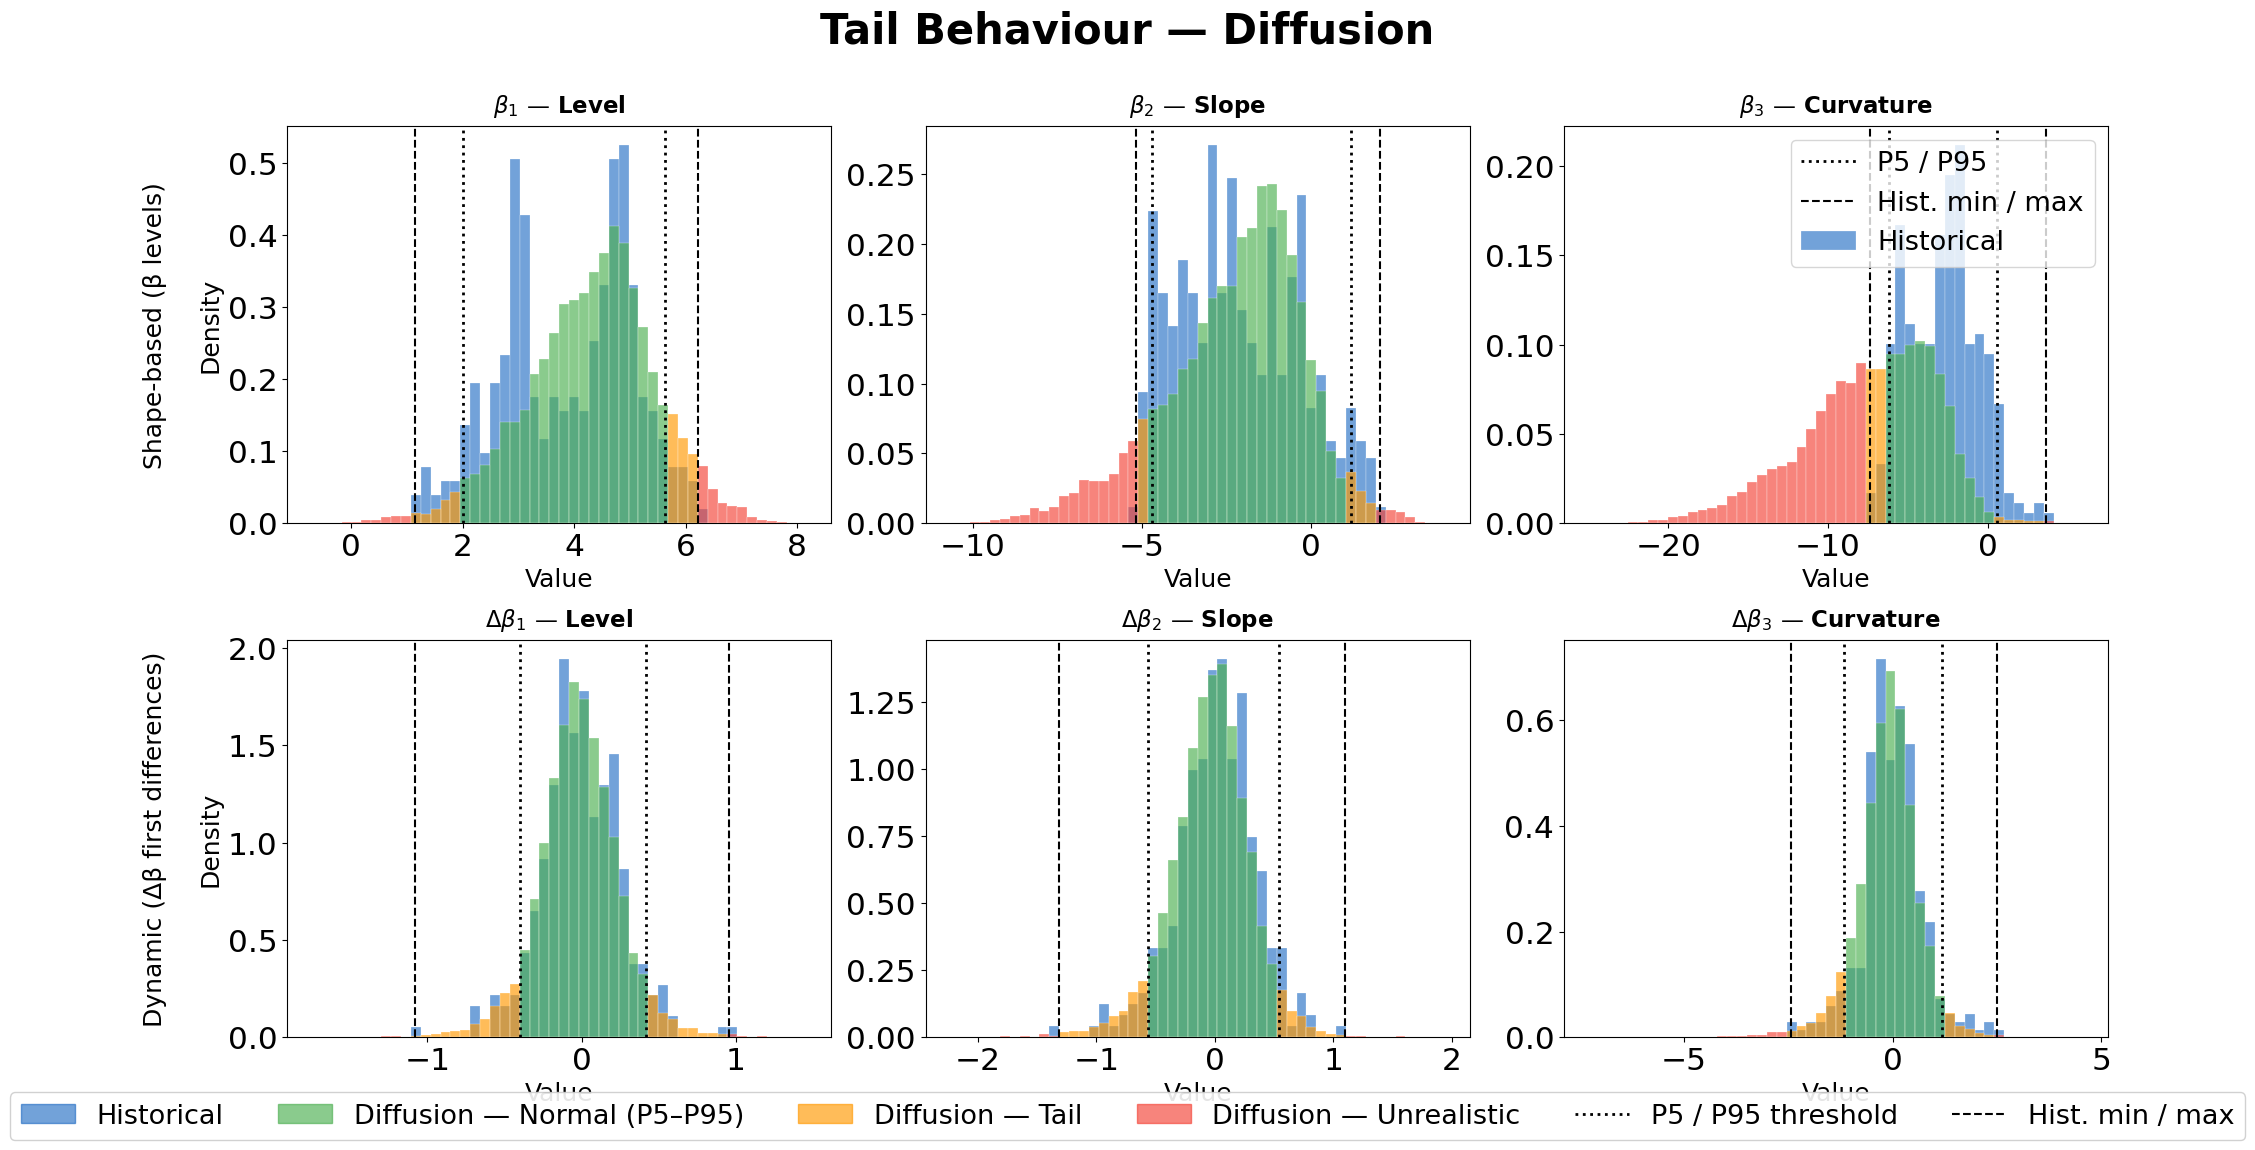

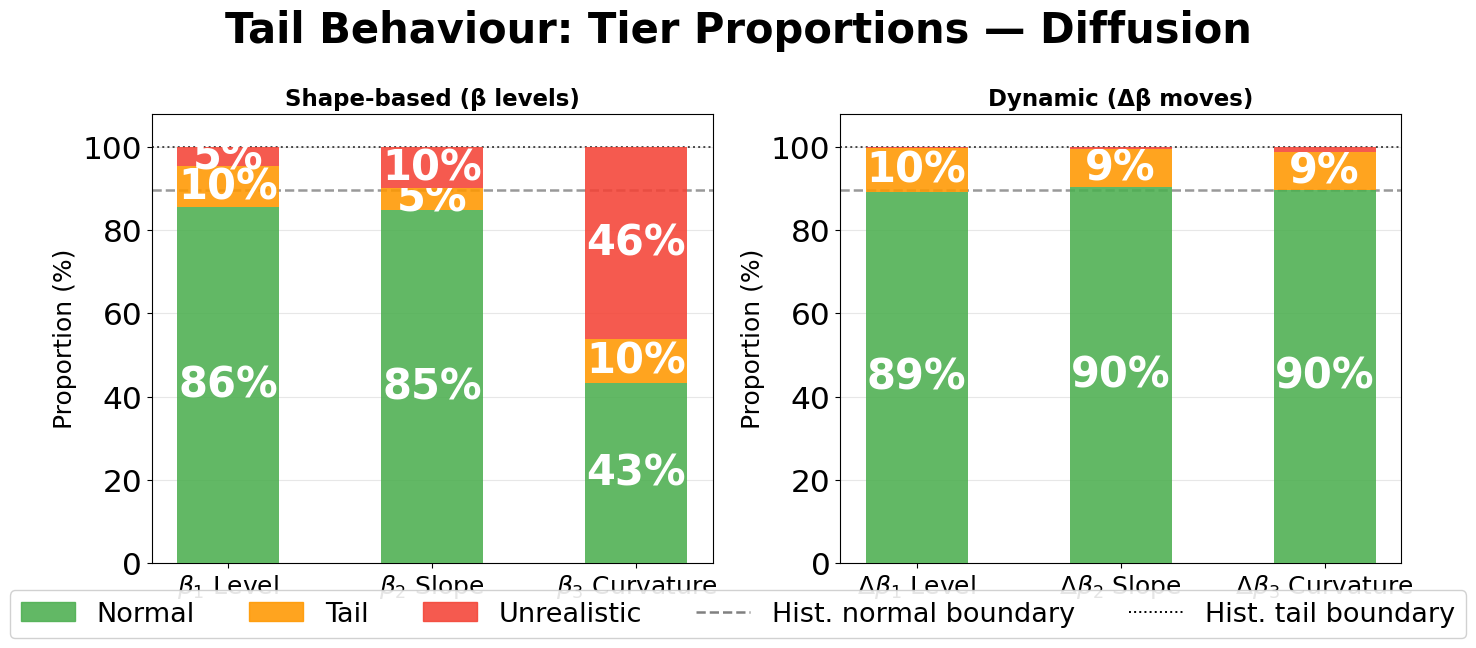

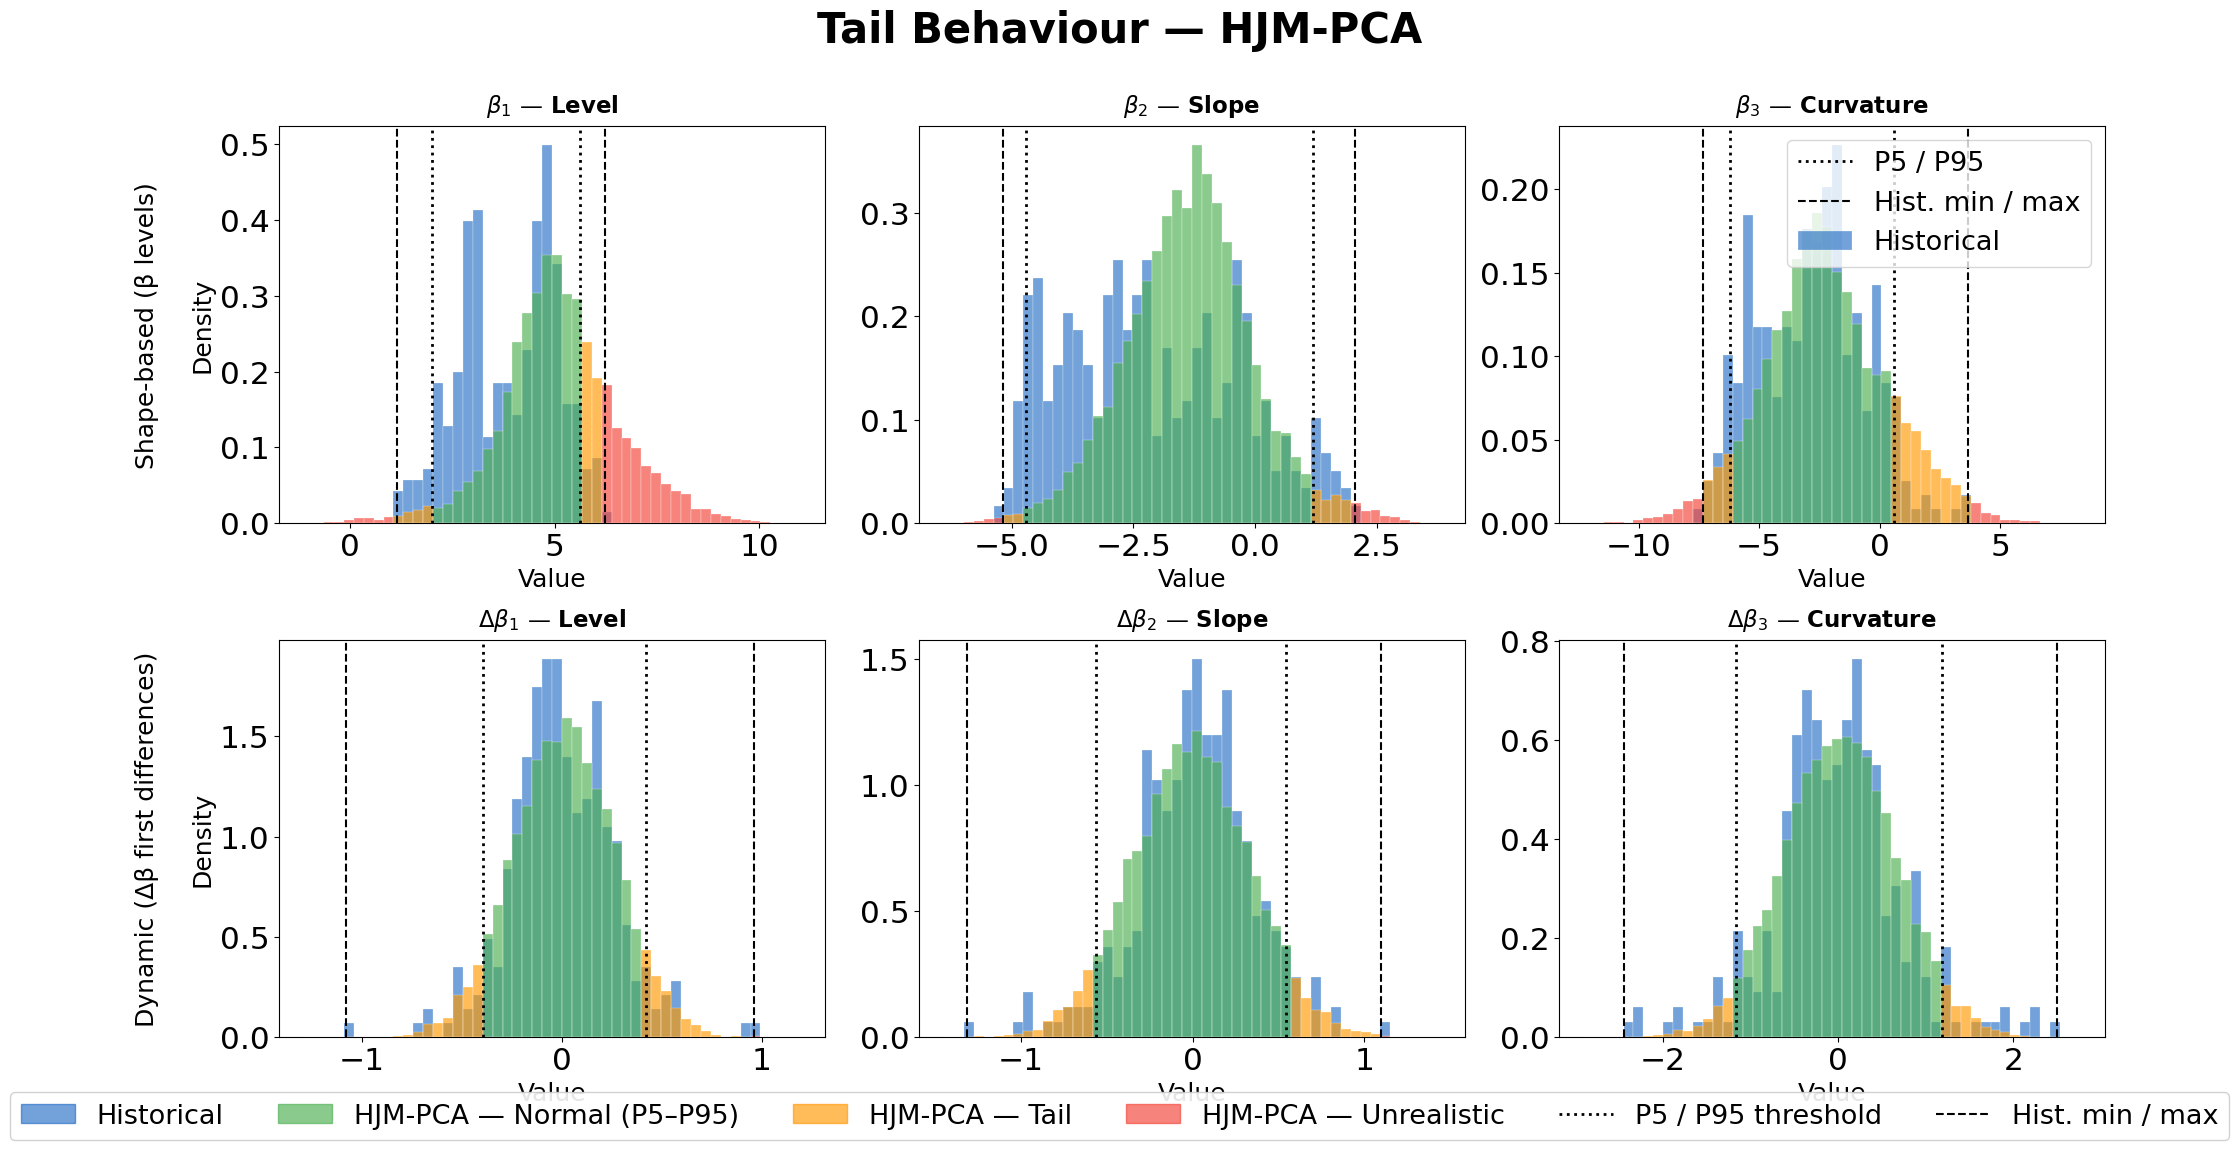

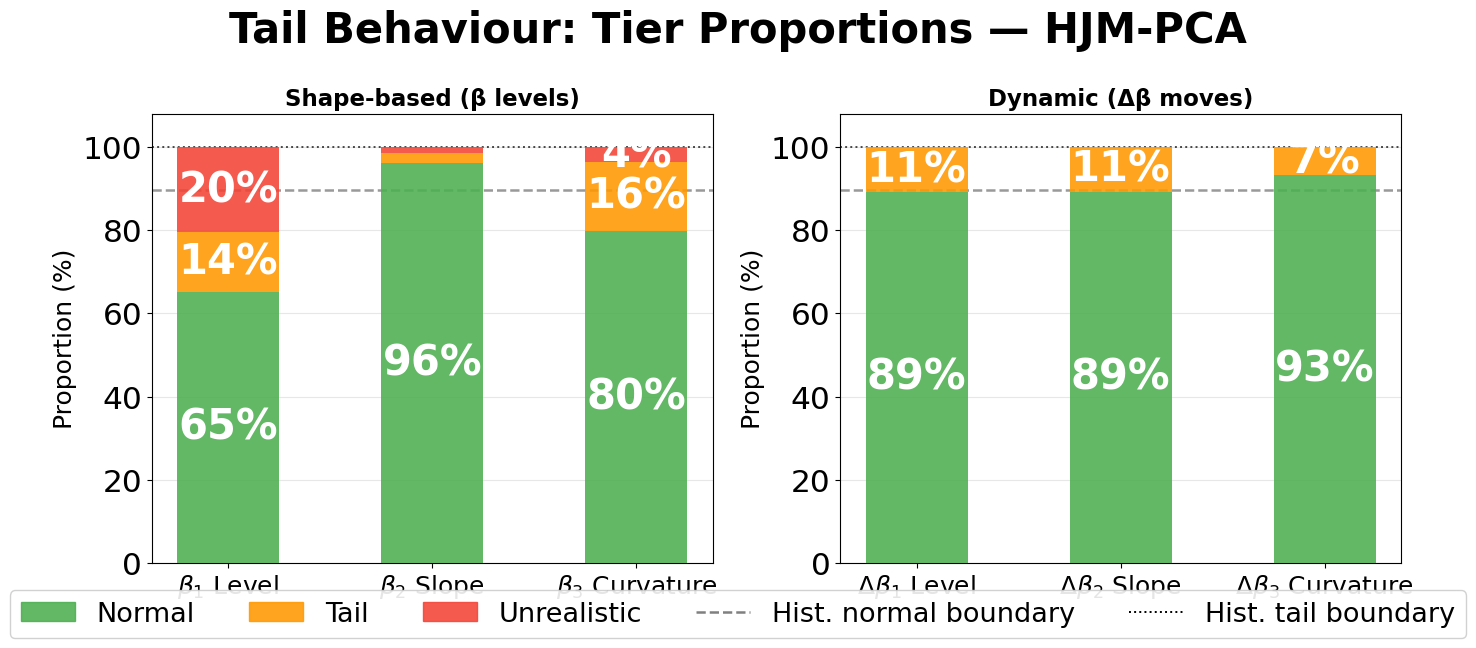

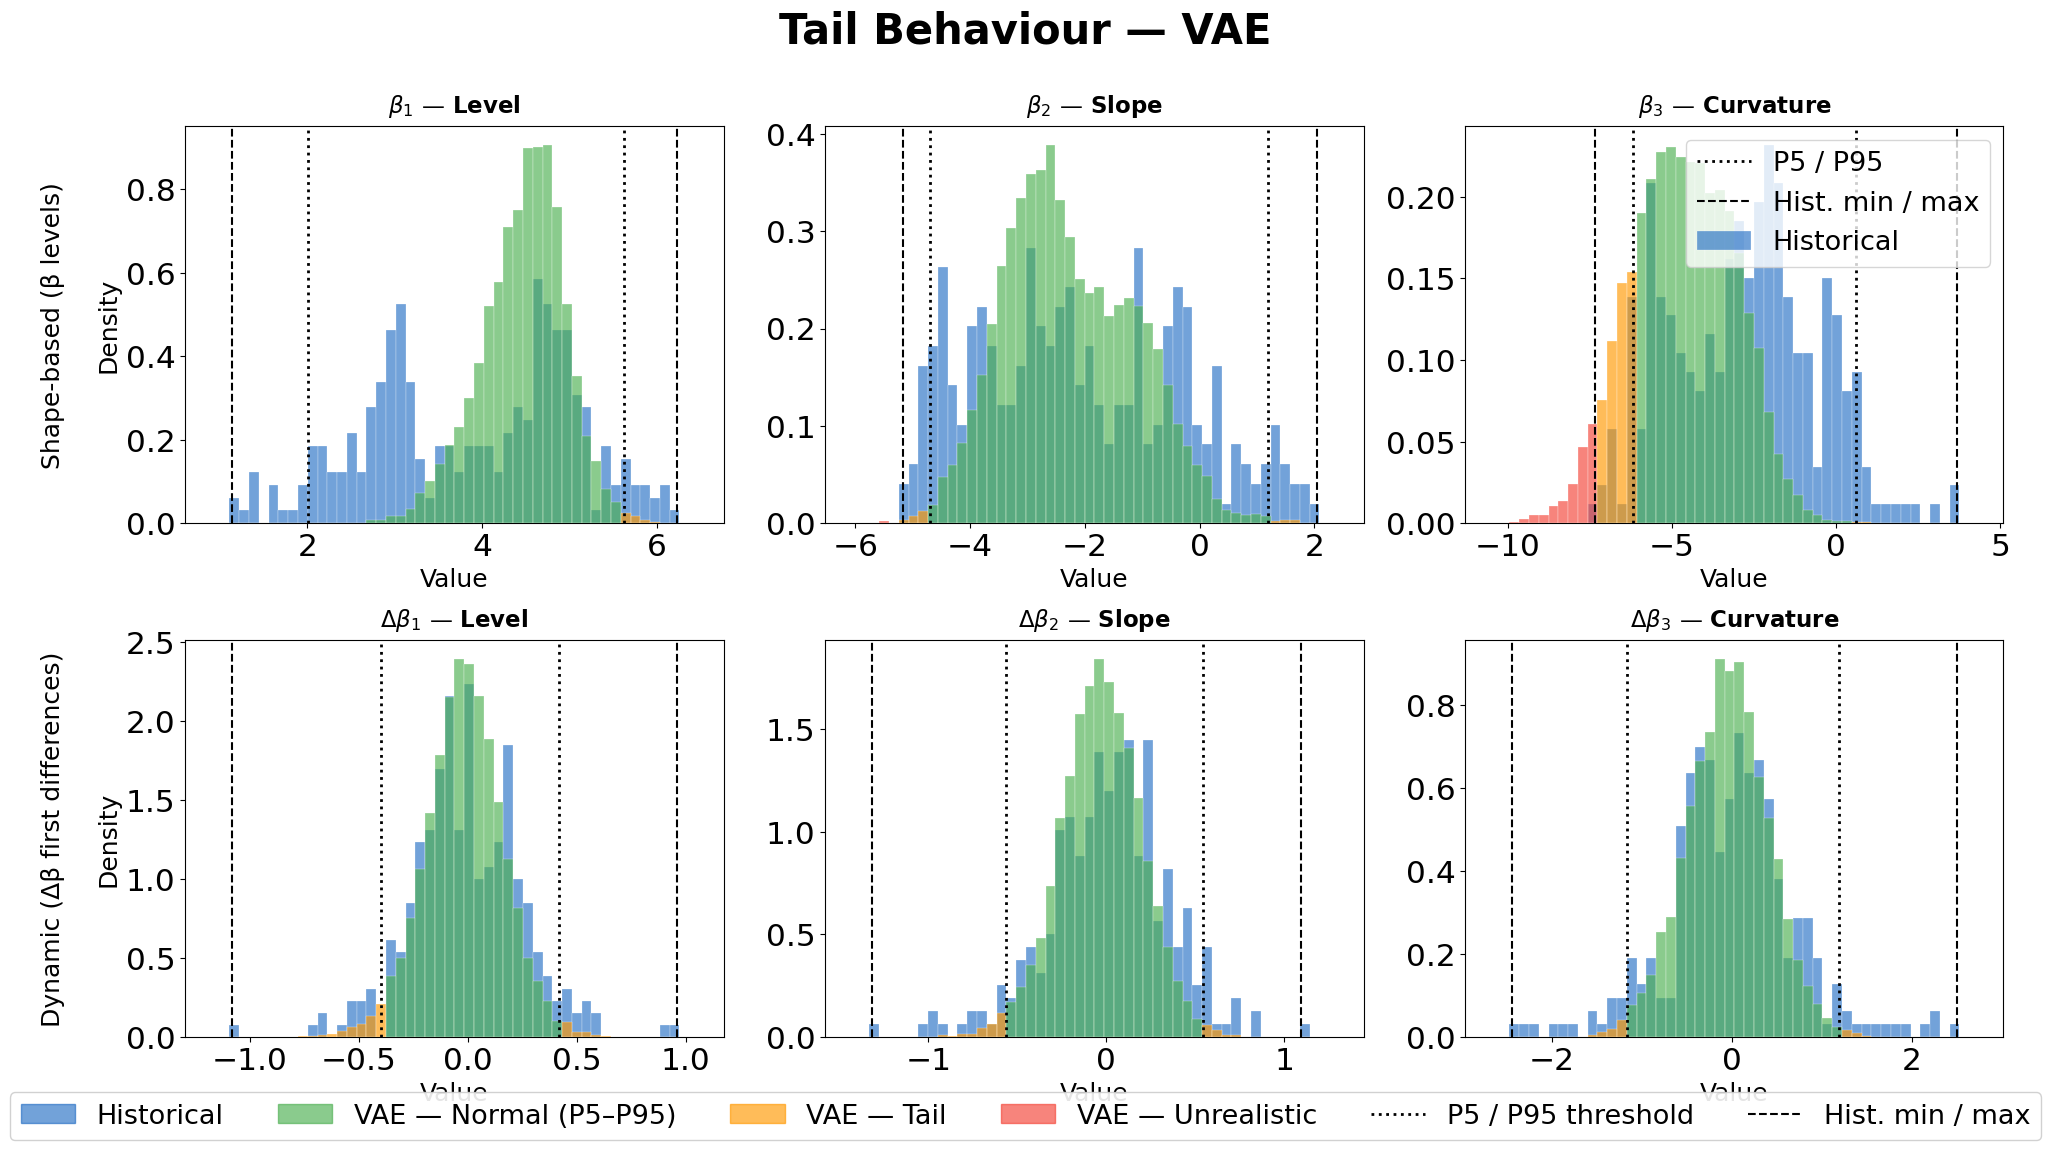

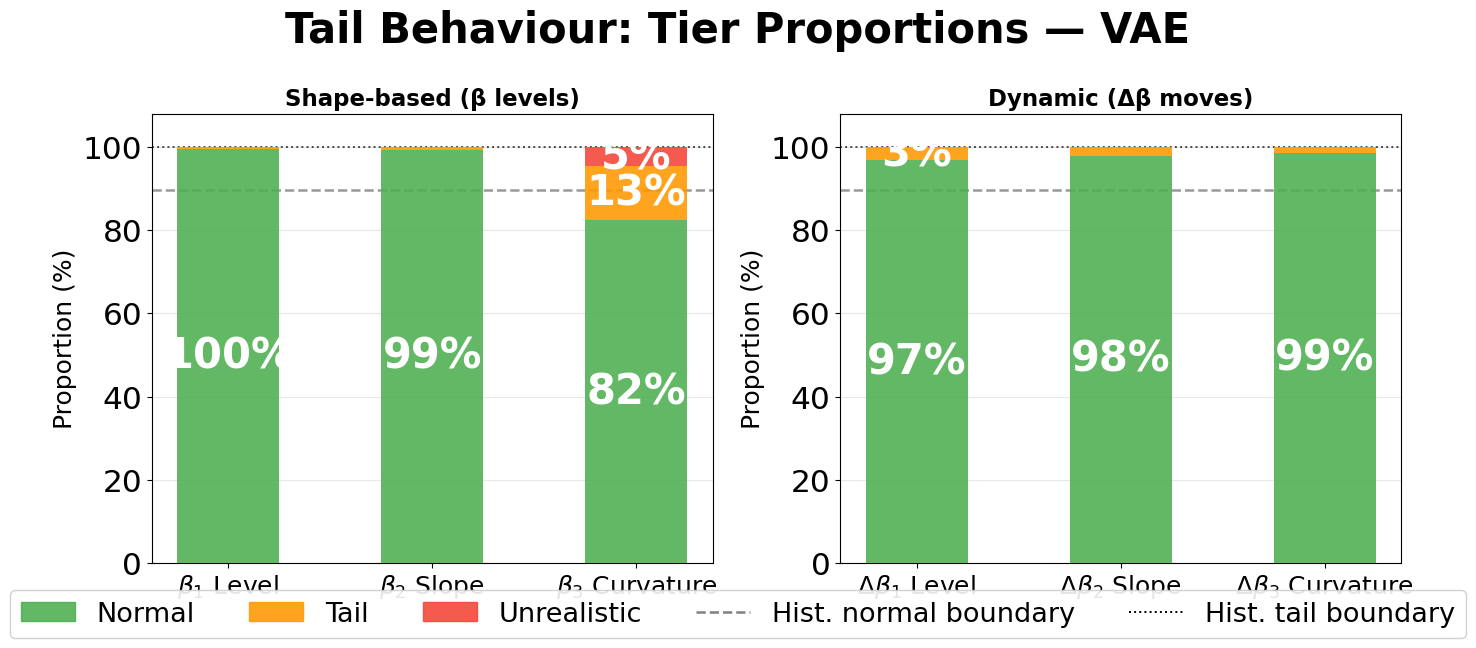

In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.7  Tail Behaviour — histograms + proportion bars
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Colours ───────────────────────────────────────────────────────────────────
C_HIST        = "#1565C0"
C_NORMAL      = "#4CAF50"
C_TAIL        = "#FF9800"
C_UNREALISTIC = "#F44336"

FACTOR_LABELS = [r"$\beta_1$ — Level", r"$\beta_2$ — Slope", r"$\beta_3$ — Curvature"]
DIFF_LABELS   = [r"$\Delta\beta_1$ — Level", r"$\Delta\beta_2$ — Slope", r"$\Delta\beta_3$ — Curvature"]
TIER_COLORS   = {"Normal": C_NORMAL, "Tail": C_TAIL, "Unrealistic": C_UNREALISTIC}
TIER_ORDER    = ["Normal", "Tail", "Unrealistic"]
N_BINS        = 50

# ── Font sizes ────────────────────────────────────────────────────────────────
FS          = 1.5
SUPTITLE_FS = 20 * FS
TITLE_FS    = 11 * FS
LABEL_FS    = 12 * FS
TICK_FS     = 15  * FS
LEGEND_FS   = 13  * FS
ANNOT_FS    = 20  * FS


# ── Histogram helper ──────────────────────────────────────────────────────────
def plot_hist_pair(ax, hist_vals, sim_vals, t_lo, t_hi, v_min, v_max):
    lo    = min(hist_vals.min(), sim_vals.min())
    hi    = max(hist_vals.max(), sim_vals.max())
    pad   = 0.05 * (hi - lo)
    edges = np.linspace(lo - pad, hi + pad, N_BINS + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    width   = edges[1] - edges[0]

    # Historical — blue
    h_counts, _ = np.histogram(hist_vals, bins=edges, density=True)
    ax.bar(centers, h_counts, width=width,
           color=C_HIST, alpha=0.6, edgecolor="white", linewidth=0.3,
           zorder=2, label="Historical")

    # Model — zone-coloured
    s_counts, _ = np.histogram(sim_vals, bins=edges, density=True)
    for c, count in zip(centers, s_counts):
        if c < v_min or c > v_max:
            color = C_UNREALISTIC
        elif c < t_lo or c > t_hi:
            color = C_TAIL
        else:
            color = C_NORMAL
        ax.bar(c, count, width=width, color=color, alpha=0.65,
               edgecolor="white", linewidth=0.3, zorder=3)

    ax.axvline(t_lo,  color="black", ls=":",  lw=2,   zorder=5, label="P5 / P95")
    ax.axvline(t_hi,  color="black", ls=":",  lw=2,   zorder=5)
    ax.axvline(v_min, color="black", ls="--", lw=1.5, zorder=5, label="Hist. min / max")
    ax.axvline(v_max, color="black", ls="--", lw=1.5, zorder=5)

if col == 0:
    ax.set_ylabel(f"{row_label}\n\nDensity", fontsize=LABEL_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.grid(alpha=0.25, zorder=0)
    ax.set_axisbelow(True)


# ── Histogram figure per model ────────────────────────────────────────────────
def dist_plot_for_model(name, betas_flat, betas_sc):
    diffs_flat = np.diff(betas_sc, axis=1).reshape(-1, 3)

    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    fig.suptitle(
        f"Tail Behaviour — {name}",
        fontsize=SUPTITLE_FS, fontweight="bold", color="black", y=1.01
    )

    row_data = [
        (hist_betas_ts, betas_flat,
         [(shape_tail_lo[i], shape_tail_hi[i], shape_min[i], shape_max[i]) for i in range(3)],
         FACTOR_LABELS, "Shape-based (β levels)"),
        (hist_diff_ts, diffs_flat,
         [(dyn_tail_lo[i], dyn_tail_hi[i], dyn_min[i], dyn_max[i]) for i in range(3)],
         DIFF_LABELS, "Dynamic (Δβ first differences)"),
    ]

    for row, (hist_vals, sim_vals, thresholds, col_labels, row_label) in enumerate(row_data):
        for col in range(3):
            ax = axes[row, col]
            t_lo, t_hi, v_min, v_max = thresholds[col]
            plot_hist_pair(ax, hist_vals[:, col], sim_vals[:, col],
                           t_lo, t_hi, v_min, v_max)
            ax.set_title(col_labels[col], fontsize=TITLE_FS, fontweight="bold", pad=10)
            ax.set_xlabel("Value", fontsize=LABEL_FS)

            ax.tick_params(axis="both", labelsize=TICK_FS)

            if col == 0:
                ax.set_ylabel(f"{row_label}\n\nDensity", fontsize=LABEL_FS)
            if row == 0 and col == 2:
                ax.legend(fontsize=LEGEND_FS, loc="upper right")

    legend_patches = [
        mpatches.Patch(color=C_HIST,        alpha=0.6,  label="Historical"),
        mpatches.Patch(color=C_NORMAL,      alpha=0.65, label=f"{name} — Normal (P5–P95)"),
        mpatches.Patch(color=C_TAIL,        alpha=0.65, label=f"{name} — Tail"),
        mpatches.Patch(color=C_UNREALISTIC, alpha=0.65, label=f"{name} — Unrealistic"),
        plt.Line2D([0],[0], color="black", ls=":",  lw=2,   label="P5 / P95 threshold"),
        plt.Line2D([0],[0], color="black", ls="--", lw=1.5, label="Hist. min / max"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=6,
               fontsize=LEGEND_FS, bbox_to_anchor=(0.5, -0.03), framealpha=0.9)
    plt.tight_layout()
    plt.show()


# ── Proportion bar chart per model ────────────────────────────────────────────
def prop_bar_plot(name, results):
    fig, (ax_s, ax_d) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Tail Behaviour: Tier Proportions — {name}",
                 fontsize=SUPTITLE_FS, fontweight="bold", color="black", y=1.01)

    for ax, kind, xlabels, ref_n, ref_t in [
        (ax_s, "shape",
         [r"$\beta_1$ Level", r"$\beta_2$ Slope", r"$\beta_3$ Curvature"],
         np.mean([tail_results["Historical"]["shape"][i][0] for i in range(3)]),
         np.mean([tail_results["Historical"]["shape"][i][1] for i in range(3)])),
        (ax_d, "dyn",
         [r"$\Delta\beta_1$ Level", r"$\Delta\beta_2$ Slope", r"$\Delta\beta_3$ Curvature"],
         np.mean([tail_results["Historical"]["dyn"][i][0] for i in range(3)]),
         np.mean([tail_results["Historical"]["dyn"][i][1] for i in range(3)])),
    ]:
        x       = np.arange(3)
        bottoms = np.zeros(3)
        for tier in TIER_ORDER:
            idx  = TIER_ORDER.index(tier)
            vals = np.array([results[kind][i][idx] * 100 for i in range(3)])
            ax.bar(x, vals, 0.5, bottom=bottoms,
                   color=TIER_COLORS[tier], alpha=0.88, zorder=3)
            for xi, (v, b) in enumerate(zip(vals, bottoms)):
                if v >= 3:
                    ax.text(xi, b + v / 2, f"{v:.0f}%",
                            ha="center", va="center",
                            fontsize=ANNOT_FS, fontweight="bold", color="white")
            bottoms += vals

        ax.axhline(ref_n * 100,              color="grey",  ls="--", lw=1.8, alpha=0.8)
        ax.axhline((ref_n + ref_t) * 100,    color="black", ls=":",  lw=1.4, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=LABEL_FS)
        ax.set_ylim(0, 108)
        ax.set_ylabel("Proportion (%)", fontsize=LABEL_FS)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        ax.yaxis.grid(True, alpha=0.3, zorder=0)
        ax.set_axisbelow(True)

    ax_s.set_title("Shape-based (β levels)",   fontsize=TITLE_FS, fontweight="bold")
    ax_d.set_title("Dynamic (Δβ moves)",        fontsize=TITLE_FS, fontweight="bold")

    patches = [mpatches.Patch(color=TIER_COLORS[t], label=t, alpha=0.88) for t in TIER_ORDER]
    patches += [
        plt.Line2D([0],[0], color="grey",  ls="--", lw=1.8, label="Hist. normal boundary"),
        plt.Line2D([0],[0], color="black", ls=":",  lw=1.4, label="Hist. tail boundary"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=5,
               fontsize=LEGEND_FS, bbox_to_anchor=(0.5, -0.06), framealpha=0.9)
    plt.tight_layout()
    plt.show()


# ── Run for all models ────────────────────────────────────────────────────────
for name, path in MODELS.items():
    tensor     = scenario_tensor(path)
    betas_flat = fit_betas(tensor.reshape(-1, 11))
    betas_sc   = np.stack([fit_betas(tensor[s]) for s in range(tensor.shape[0])])
    dist_plot_for_model(name, betas_flat, betas_sc)
    prop_bar_plot(name, tail_results[name])

## 4.8 Fat Tail — Kurtosis of Monthly Yield Changes

Following CoFinDiff (Tanaka et al., 2025), fat-tail behaviour is assessed using **Fisher's bias-corrected excess kurtosis** applied to monthly yield changes.  
The calculation mirrors the CoFinDiff approach: first differences are taken within each 60-month window (historical) or scenario (models), giving 59 monthly changes per path. Kurtosis is then computed per maturity per path and reported as **mean ± std** across all windows / scenarios.

- **Positive excess kurtosis** → fat tails (more extreme moves than a normal distribution)
- **≈ 0** → tails close to normal (GBM / GARCH-like behaviour)
- A good generative model should reproduce the positive kurtosis observed in historical yield changes.

Fitting NS to historical windows...
Fitting NS to model scenarios...
  Diffusion...
  HJM-PCA...
  VAE...

  Fisher's Excess Kurtosis of Monthly NS Factor Changes (Δβ)
  Format: mean (+/- std)  |  positive = fat tails
                 β1 (Level)       β2 (Slope)   β3 (Curvature) Mean (all)
Model                                                                   
Historical   1.06 (+/-1.53)   0.75 (+/-0.99)   1.07 (+/-0.93)       0.96
Diffusion    1.18 (+/-1.39)   1.56 (+/-2.25)   2.24 (+/-2.39)       1.66
HJM-PCA     -0.04 (+/-0.61)  -0.01 (+/-0.60)  -0.02 (+/-0.49)      -0.02
VAE          0.26 (+/-0.80)   0.04 (+/-0.62)   0.00 (+/-0.70)       0.10



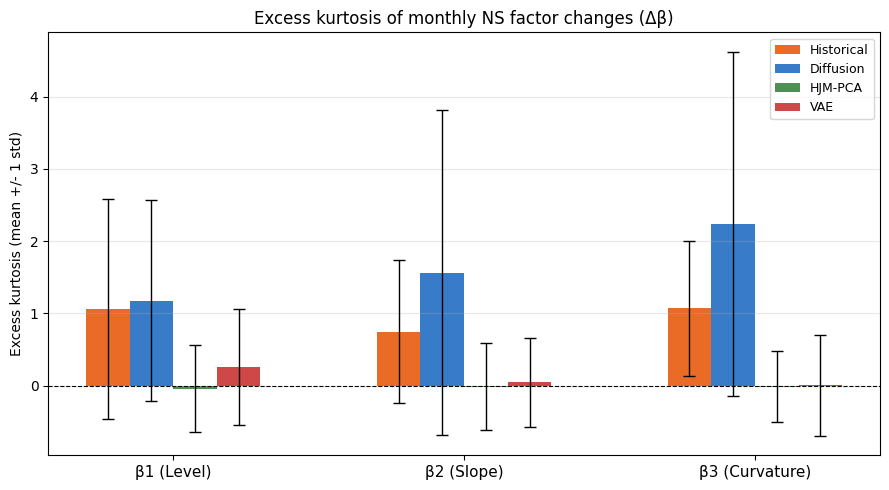

In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.8  Fat Tail — Fisher's excess kurtosis of monthly NS factor changes
# ─────────────────────────────────────────────────────────────────────────────
# Methodology (CoFinDiff, Tanaka et al. 2025, eq. 3):
#   • Fit Nelson-Siegel to every yield curve observation → β1, β2, β3
#   • Take monthly first-differences within each 60-month path → Δβ1, Δβ2, Δβ3
#   • Compute bias-corrected Fisher's excess kurtosis per path × factor
#   • Report mean ± std across rolling windows (historical) / scenarios (models)
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis as scipy_kurtosis
import warnings
warnings.filterwarnings("ignore")

NS_LAMBDA   = 0.0609
MATS_MONTHS = np.array([1/12,3/12,6/12,1,2,3,5,7,10,20,30]) * 12
FACTOR_LABELS = ["β1 (Level)", "β2 (Slope)", "β3 (Curvature)"]

def ns_loadings(mats, lam):
    lt = lam * mats
    return np.column_stack([np.ones_like(lt),
                             (1 - np.exp(-lt)) / lt,
                             (1 - np.exp(-lt)) / lt - np.exp(-lt)])

def fit_ns_batch(arr):
    """
    arr : (N, T, 11) — N paths, T timesteps, 11 maturities
    Returns (N, T, 3) — NS betas fitted to every yield curve observation.
    """
    X = ns_loadings(MATS_MONTHS, NS_LAMBDA)          # (11, 3)
    N, T, M = arr.shape
    betas = np.zeros((N, T, 3))
    for n in range(N):
        for t in range(T):
            b, _, _, _ = np.linalg.lstsq(X, arr[n, t], rcond=None)
            betas[n, t] = b
    return betas                                      # (N, T, 3)

def fisher_kurtosis_per_path(arr):
    """
    arr : (N, T, 3) — NS betas per path
    Returns (N, 3) — bias-corrected Fisher excess kurtosis of Δβ per path × factor.
    """
    changes = np.diff(arr, axis=1)                   # (N, T-1, 3)
    N, Tm1, F = changes.shape
    kurt = np.zeros((N, F))
    for n in range(N):
        for f in range(F):
            s = changes[n, :, f]
            if s.std() > 1e-10:
                kurt[n, f] = scipy_kurtosis(s, fisher=True, bias=False)
    return kurt                                       # (N, 3)

# ── Compute NS betas and kurtosis ─────────────────────────────────────────────
print("Fitting NS to historical windows...")
hist_betas_paths = fit_ns_batch(hist_windows)                    # (n_windows, 60, 3)
hist_kurt        = fisher_kurtosis_per_path(hist_betas_paths)    # (n_windows, 3)

print("Fitting NS to model scenarios...")
sim_kurt = {}
for name, path in MODELS.items():
    print(f"  {name}...")
    tens = scenario_tensor(path)                                  # (200, 60, 11)
    betas = fit_ns_batch(tens)                                    # (200, 60, 3)
    sim_kurt[name] = fisher_kurtosis_per_path(betas)             # (200, 3)

all_sources = {"Historical": hist_kurt, **sim_kurt}

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for source_name, kurt_arr in all_sources.items():
    row = {"Model": source_name}
    for f, fname in enumerate(FACTOR_LABELS):
        m = kurt_arr[:, f].mean()
        s = kurt_arr[:, f].std()
        row[fname] = f"{m:.2f} (+/-{s:.2f})"
    row["Mean (all)"] = f"{kurt_arr.mean():.2f}"
    rows.append(row)

df_kurt = pd.DataFrame(rows).set_index("Model")

print()
print("=" * 75)
print("  Fisher's Excess Kurtosis of Monthly NS Factor Changes (Δβ)")
print("  Format: mean (+/- std)  |  positive = fat tails")
print("=" * 75)
print(df_kurt.to_string())
print()

# ── Plot ──────────────────────────────────────────────────────────────────────
MODEL_COLORS = {
    "Historical": "#E65100",
    "Diffusion":  "#1565C0",
    "HJM-PCA":    "#2E7D32",
    "CANN":       "#6A1B9A",
    "VAE":        "#C62828",
}

x = np.arange(len(FACTOR_LABELS))
width = 0.15
n_models = len(all_sources)
offsets = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * width

fig, ax = plt.subplots(figsize=(9, 5))

for i, (source_name, kurt_arr) in enumerate(all_sources.items()):
    means = kurt_arr.mean(axis=0)
    stds  = kurt_arr.std(axis=0)
    c = MODEL_COLORS.get(source_name, "grey")
    ax.bar(x + offsets[i], means, width, label=source_name,
           color=c, alpha=0.85, yerr=stds, capsize=4, ecolor="black", error_kw={"lw": 1})

ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(FACTOR_LABELS, fontsize=11)
ax.set_ylabel("Excess kurtosis (mean +/- 1 std)")
ax.set_title("Excess kurtosis of monthly NS factor changes (Δβ)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
# ── Mean kurtosis summary table ──────────────────────────────────────────────

mean_kurtosis_df = pd.DataFrame({
    name: kurt_arr.mean(axis=0)
    for name, kurt_arr in all_sources.items()
}, index=FACTOR_LABELS).T

print()
print("=" * 75)
print("Mean Fisher Excess Kurtosis of Monthly NS Factor Changes (Δβ)")
print("=" * 75)

print(mean_kurtosis_df.round(3).to_string())

print()


Mean Fisher Excess Kurtosis of Monthly NS Factor Changes (Δβ)
            β1 (Level)  β2 (Slope)  β3 (Curvature)
Historical       1.061       0.747           1.068
Diffusion        1.175       1.563           2.237
HJM-PCA         -0.040      -0.014          -0.015
VAE              0.263       0.044           0.002



In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.8  Tail Behaviour — percentage tables
# Reports Normal / Tail / Unrealistic proportions per factor
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd

def make_tail_table(name, results):
    rows = []

    # Shape-based β levels
    for i, label in enumerate(["Level β1", "Slope β2", "Curvature β3"]):
        normal, tail, unreal = results["shape"][i]

        rows.append({
            "Model": name,
            "Category": "Shape-based (β levels)",
            "Factor": label,
            "Normal (%)": round(normal * 100, 2),
            "Tail (%)": round(tail * 100, 2),
            "Unrealistic (%)": round(unreal * 100, 2),
        })

    # Dynamic Δβ differences
    for i, label in enumerate(["ΔLevel β1", "ΔSlope β2", "ΔCurvature β3"]):
        normal, tail, unreal = results["dyn"][i]

        rows.append({
            "Model": name,
            "Category": "Dynamic (Δβ moves)",
            "Factor": label,
            "Normal (%)": round(normal * 100, 2),
            "Tail (%)": round(tail * 100, 2),
            "Unrealistic (%)": round(unreal * 100, 2),
        })

    return pd.DataFrame(rows)


# ── Create tables for all models ─────────────────────────────────────────────
all_tables = []

for name in MODELS.keys():
    df_table = make_tail_table(name, tail_results[name])

    print("\n" + "="*80)
    print(f"TAIL BEHAVIOUR TABLE — {name}")
    print("="*80)

    print(df_table.to_string(index=False))

    all_tables.append(df_table)

# Combine all models into one dataframe
final_table = pd.concat(all_tables, ignore_index=True)

print("\nSaved: tail_behaviour_percentages.csv")


TAIL BEHAVIOUR TABLE — Diffusion
    Model               Category        Factor  Normal (%)  Tail (%)  Unrealistic (%)
Diffusion Shape-based (β levels)      Level β1       85.52      9.85             4.62
Diffusion Shape-based (β levels)      Slope β2       84.80      5.28             9.93
Diffusion Shape-based (β levels)  Curvature β3       43.28     10.48            46.24
Diffusion     Dynamic (Δβ moves)     ΔLevel β1       89.32     10.44             0.24
Diffusion     Dynamic (Δβ moves)     ΔSlope β2       90.46      9.12             0.42
Diffusion     Dynamic (Δβ moves) ΔCurvature β3       89.71      9.13             1.16

TAIL BEHAVIOUR TABLE — HJM-PCA
  Model               Category        Factor  Normal (%)  Tail (%)  Unrealistic (%)
HJM-PCA Shape-based (β levels)      Level β1       65.17     14.39            20.44
HJM-PCA Shape-based (β levels)      Slope β2       96.12      2.55             1.32
HJM-PCA Shape-based (β levels)  Curvature β3       79.91     16.47             3

## 4.9 Diversity

Diversity is assessed by extracting three financially interpretable features from every yield curve observation and measuring how widely the generated scenarios span each dimension:

- **Level** = average yield across all 11 maturities — captures parallel shifts
- **Slope** = 30Y yield − 3M yield — captures whether the curve is upward-sloping, flat, or inverted
- **Curvature** = 10Y − 0.5 × (3M + 30Y) — captures hump-shaped or U-shaped structures

High standard deviation and wide range across features indicate diverse scenario coverage. Very small dispersion signals mode collapse.

In [59]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.9  Diversity — compute curve-level features
# ─────────────────────────────────────────────────────────────────────────────
# Three financially interpretable summary statistics per yield curve:
#   Level     = average yield across all 11 maturities (parallel shifts)
#   Slope     = 30Y yield − 3M yield     (steepness / inversion)
#   Curvature = 10Y − 0.5 × (3M + 30Y)  (hump-shaped vs U-shaped)
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

_HIST_YLD = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
             "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]
_SIM_YLD  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
             "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]

def curve_features(df, yield_cols):
    """
    Extract Level, Slope, Curvature from a DataFrame of yield curves.
    Returns pd.DataFrame with columns ['Level', 'Slope', 'Curvature'].
    """
    Y         = df[yield_cols].values                         # (N, 11)
    level     = Y.mean(axis=1)
    slope     = Y[:, 10] - Y[:, 1]                           # 30Y − 3M
    curvature = Y[:, 8]  - 0.5 * (Y[:, 1] + Y[:, 10])       # 10Y − 0.5*(3M+30Y)
    return pd.DataFrame({"Level": level, "Slope": slope, "Curvature": curvature})

# Historical features (monthly observations)
hist_feat = curve_features(hist_monthly, _HIST_YLD)
print(f"Historical features : {hist_feat.shape}")

# Model features (all scenario observations flattened)
sim_feat = {}
for name, path in MODELS.items():
    df = load_scenarios(path)
    sim_feat[name] = curve_features(df, _SIM_YLD)
    print(f"  {name:12s}: {sim_feat[name].shape[0]:,} observations")

print("Diversity features computed.")


Historical features : (290, 3)
  Diffusion   : 12,000 observations
  HJM-PCA     : 12,000 observations
  VAE         : 12,000 observations
Diversity features computed.


In [60]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.9  Diversity — summary table  (Mean, Std Dev, Min, Max, Range)
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

features  = ["Level", "Slope", "Curvature"]
stats_lbl = ["Mean", "Std Dev", "Min", "Max", "Range"]

all_datasets = {"Historical": hist_feat, **sim_feat}

rows = []
for name, feat_df in all_datasets.items():
    for feat in features:
        v = feat_df[feat].values
        rows.append({
            "Model":   name,
            "Feature": feat,
            "Mean":    round(v.mean(), 3),
            "Std Dev": round(v.std(),  3),
            "Min":     round(v.min(),  3),
            "Max":     round(v.max(),  3),
            "Range":   round(v.max() - v.min(), 3),
        })

div_df = pd.DataFrame(rows).set_index(["Model", "Feature"])

print("=" * 72)
print("  Diversity Summary — Level / Slope / Curvature")
print("  Higher Std Dev and Range = more diverse scenario coverage")
print("=" * 72)
print(div_df.to_string())

# ── Compact ranking table by Std Dev (most readable for thesis) ───────────────
print("\n" + "=" * 55)
print("  Std Dev ranking per feature  (higher = more diverse)")
print("=" * 55)
pivot_std = (div_df["Std Dev"]
             .unstack("Feature")[features]
             .rename_axis(None, axis=1))
pivot_std["Avg Std Dev"] = pivot_std.mean(axis=1)
pivot_std = pivot_std.sort_values("Avg Std Dev", ascending=False)
print(pivot_std.round(3).to_string())

print("\n" + "=" * 55)
print("  Range ranking per feature  (higher = more diverse)")
print("=" * 55)
pivot_range = (div_df["Range"]
               .unstack("Feature")[features]
               .rename_axis(None, axis=1))
pivot_range["Avg Range"] = pivot_range.mean(axis=1)
pivot_range = pivot_range.sort_values("Avg Range", ascending=False)
print(pivot_range.round(3).to_string())


  Diversity Summary — Level / Slope / Curvature
  Higher Std Dev and Range = more diverse scenario coverage
                       Mean  Std Dev    Min     Max   Range
Model      Feature                                         
Historical Level      2.476    1.375  0.358   5.176   4.818
           Slope      2.018    1.616 -1.670   4.600   6.270
           Curvature  0.392    0.556 -1.045   1.605   2.650
Diffusion  Level      2.094    1.450 -2.202   5.657   7.859
           Slope      2.493    1.735 -2.253   8.759  11.012
           Curvature  0.066    0.883 -3.406   3.639   7.046
HJM-PCA    Level      4.160    1.366 -1.541  10.059  11.600
           Slope      1.356    1.176 -2.870   5.998   8.868
           Curvature  0.129    0.514 -1.766   1.801   3.567
VAE        Level      2.686    0.892  0.653   5.429   4.776
           Slope      2.240    1.007 -1.420   4.977   6.398
           Curvature  0.242    0.368 -1.085   1.597   2.682

  Std Dev ranking per feature  (higher = more diver

# Novelty

Historical observations: 232
Lower threshold (P5  of NN distances)      : 0.0295
Upper threshold (P95 of all pairwise dists): 5.9211


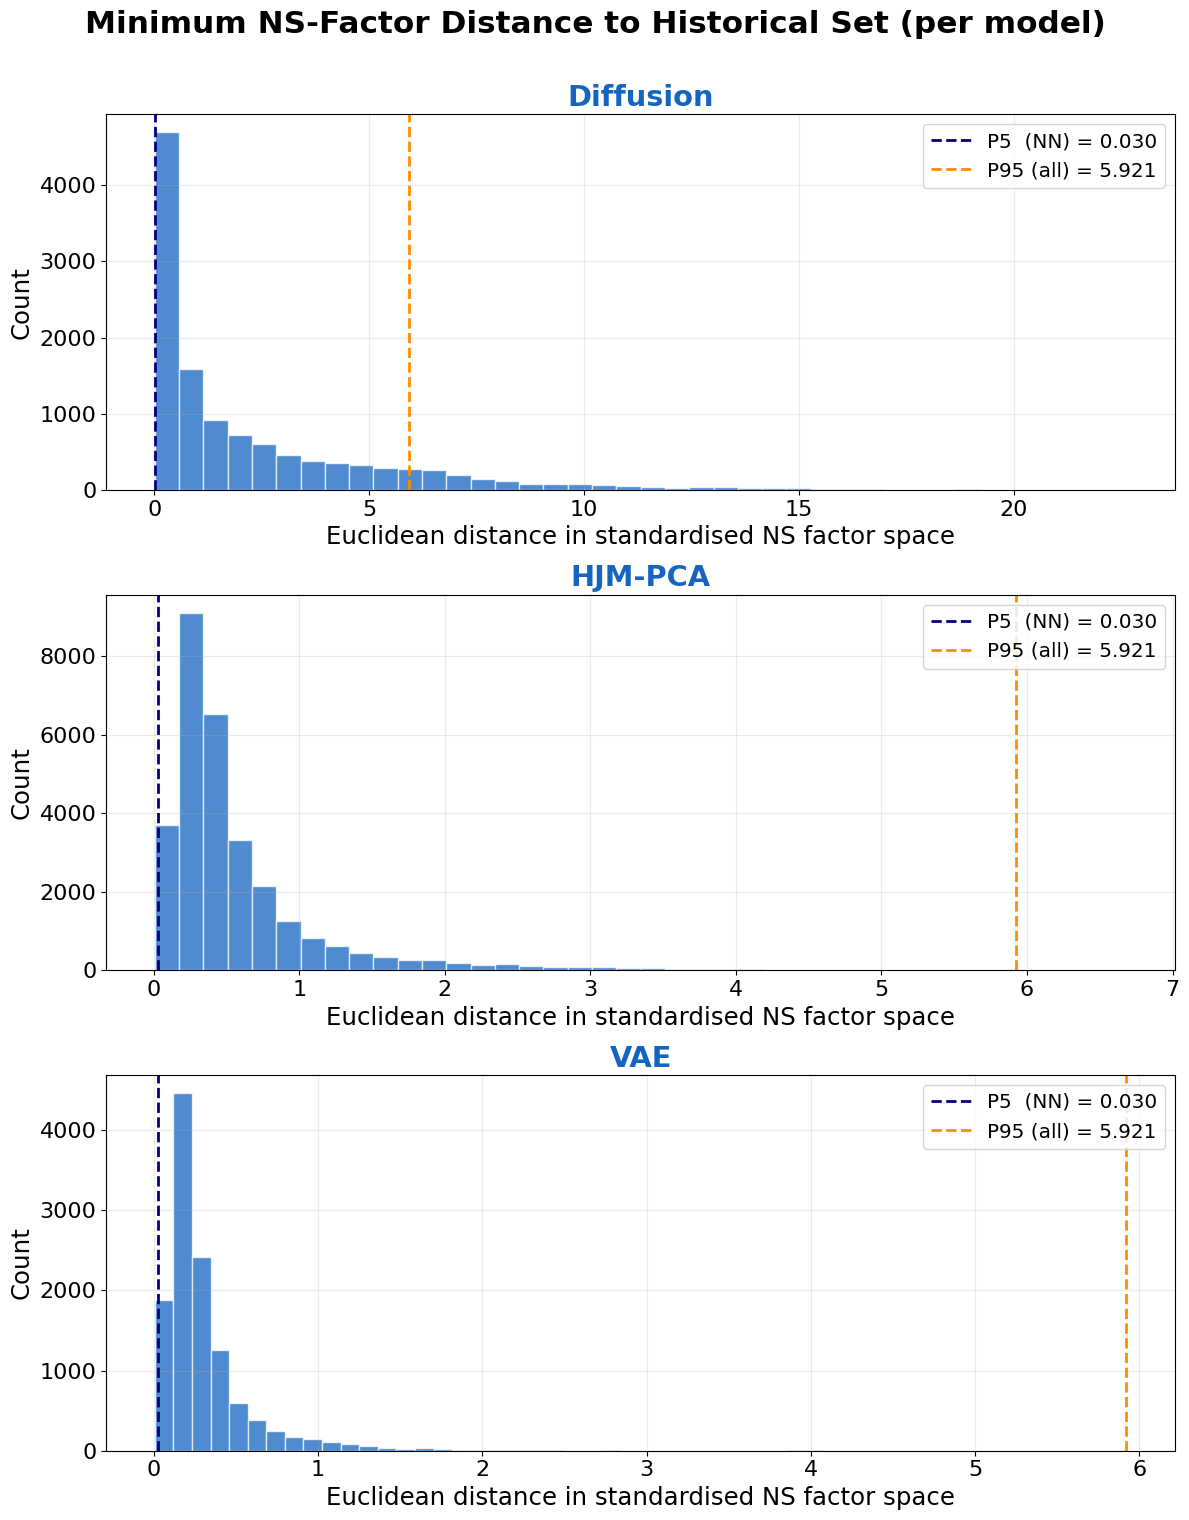

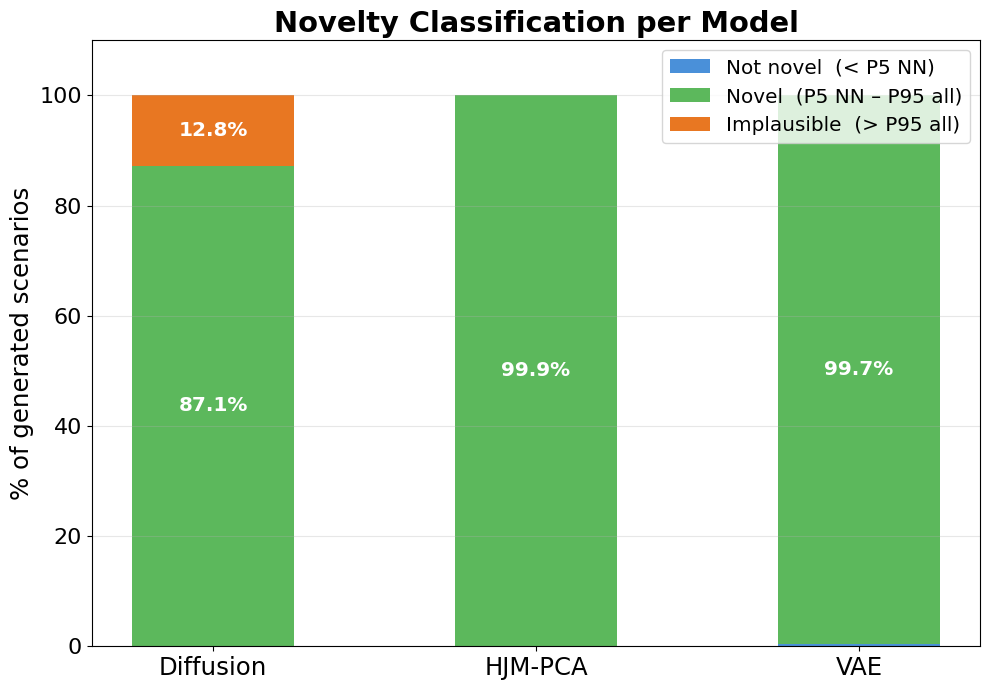

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ── file paths ────────────────────────────────────────────────────────────────
HISTORICAL = "historical data train.csv"
DIFFUSION  = "9-5 3V Diffusion.csv"
HJM        = "hjm_pca_scenarios monthly basis 24-4.csv"
VAE        = "8-5 18.0 (900 epochs) generated_yield_curve_scenarios_nodate.csv"

HIST_COLS = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
             "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]
SIM_COLS  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
             "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]

# ── Nelson-Siegel setup ───────────────────────────────────────────────────────
LAMBDA   = 0.0609
MATS_YR  = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])

def ns_loadings(maturities, lam):
    """Returns (N_maturities, 3) loading matrix for β1, β2, β3."""
    lt  = lam * maturities
    L1  = np.ones_like(lt)
    L2  = (1 - np.exp(-lt)) / lt
    L3  = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

B = ns_loadings(MATS_YR, LAMBDA)

def fit_ns_factors(yields):
    """OLS fit of NS factors for each yield curve row. Returns (N, 3) array."""
    BtB_inv_Bt = np.linalg.lstsq(B, yields.T, rcond=None)[0].T
    return BtB_inv_Bt

# ── 1. load & convert historical data to NS factors ───────────────────────────
hist       = pd.read_csv(HISTORICAL, parse_dates=["DATE"]).set_index("DATE").sort_index()
hist_ylds  = hist[HIST_COLS].resample("ME").last().dropna().values
hist_ns    = fit_ns_factors(hist_ylds)

print(f"Historical observations: {hist_ns.shape[0]}")

# ── 2. load & convert generated scenarios to NS factors ───────────────────────
def load_sim_ns(path):
    df   = pd.read_csv(path)
    ylds = df[SIM_COLS].dropna().values
    return fit_ns_factors(ylds)

models = {
    "Diffusion": load_sim_ns(DIFFUSION),
    "HJM-PCA":   load_sim_ns(HJM),
    "VAE":       load_sim_ns(VAE),
}

# ── 3. standardise NS factors ─────────────────────────────────────────────────
hist_mean = hist_ns.mean(axis=0)
hist_std  = hist_ns.std(axis=0)

def standardise(factors):
    return (factors - hist_mean) / hist_std

hist_ns_z = standardise(hist_ns)
models    = {name: standardise(ns) for name, ns in models.items()}

# ── 4. calibrate thresholds ───────────────────────────────────────────────────
D_nn = cdist(hist_ns_z, hist_ns_z, metric="euclidean")
np.fill_diagonal(D_nn, np.inf)
nn_dists = D_nn.min(axis=1)
LOWER    = np.percentile(nn_dists, 5)

np.fill_diagonal(D_nn, 0)
all_dists = D_nn[np.triu_indices_from(D_nn, k=1)]
UPPER     = np.percentile(all_dists, 99)

print(f"Lower threshold (P5  of NN distances)      : {LOWER:.4f}")
print(f"Upper threshold (P95 of all pairwise dists): {UPPER:.4f}")

# ── 5. min distance of each generated curve to the historical NS set ──────────
def min_dist_to_hist(generated_ns_z, historical_ns_z):
    D = cdist(generated_ns_z, historical_ns_z, metric="euclidean")
    return D.min(axis=1)

model_dists = {name: min_dist_to_hist(ns_z, hist_ns_z)
               for name, ns_z in models.items()}

# ── Font sizes ────────────────────────────────────────────────────────────────
FS         = 1.6
TITLE_FS   = 13 * FS
LABEL_FS   = 11 * FS
TICK_FS    = 10 * FS
LEGEND_FS  = 9  * FS
SUPTITLE_FS= 14 * FS

BAR_COLOR  = "#1565C0"   # single colour used across all figures

# ── PLOT 1 — distance distributions, one row per model ───────────────────────
n_models = len(models)
fig1, axes1 = plt.subplots(n_models, 1, figsize=(12, 5 * n_models), sharex=False)
fig1.suptitle("Minimum NS-Factor Distance to Historical Set (per model)",
              fontsize=SUPTITLE_FS, fontweight="bold", y=1.01)

for ax, (name, dists) in zip(axes1, model_dists.items()):
    ax.hist(dists, bins=40, color=BAR_COLOR, alpha=0.75, edgecolor="white")
    ax.axvline(LOWER, color="navy",       ls="--", lw=2,
               label=f"P5  (NN) = {LOWER:.3f}")
    ax.axvline(UPPER, color="darkorange", ls="--", lw=2,
               label=f"P95 (all) = {UPPER:.3f}")
    ax.set_title(name, fontsize=TITLE_FS, fontweight="bold", color=BAR_COLOR)
    ax.set_xlabel("Euclidean distance in standardised NS factor space", fontsize=LABEL_FS)
    ax.set_ylabel("Count", fontsize=LABEL_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.legend(loc="upper right", fontsize=LEGEND_FS)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("novelty_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── PLOT 2 — stacked bar: % not novel / novel / implausible ──────────────────
labels, not_novel_pct, novel_pct, implaus_pct = [], [], [], []

for name, dists in model_dists.items():
    labels.append(name)
    not_novel_pct.append(100 * np.mean(dists < LOWER))
    novel_pct.append(    100 * np.mean((dists >= LOWER) & (dists <= UPPER)))
    implaus_pct.append(  100 * np.mean(dists > UPPER))

x = np.arange(len(labels))
w = 0.5

fig2, ax2 = plt.subplots(figsize=(10, 7))
b1 = ax2.bar(x, not_novel_pct, w, label="Not novel  (< P5 NN)",     color="#4A90D9")
b2 = ax2.bar(x, novel_pct,     w, bottom=not_novel_pct,
             label="Novel  (P5 NN – P95 all)",  color="#5CB85C")
b3 = ax2.bar(x, implaus_pct,   w,
             bottom=[a + b for a, b in zip(not_novel_pct, novel_pct)],
             label="Implausible  (> P95 all)",  color="#E87722")

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=LABEL_FS)
ax2.set_ylabel("% of generated scenarios", fontsize=LABEL_FS)
ax2.set_title("Novelty Classification per Model",
              fontsize=TITLE_FS, fontweight="bold")
ax2.legend(loc="upper right", fontsize=LEGEND_FS)
ax2.set_ylim(0, 110)
ax2.tick_params(axis="y", labelsize=TICK_FS)
ax2.grid(axis="y", alpha=0.3)

for i in range(len(labels)):
    cumulative = 0
    for vals in [not_novel_pct, novel_pct, implaus_pct]:
        h = vals[i]
        if h > 3:
            ax2.text(i, cumulative + h / 2, f"{h:.1f}%",
                     ha="center", va="center",
                     fontsize=LEGEND_FS, fontweight="bold", color="white")
        cumulative += h

plt.tight_layout()
plt.savefig("novelty_bars.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
# ── Summary table ─────────────────────────────────────────────────────────────

summary_df = pd.DataFrame({
    "Model": labels,
    "Not Novel (%)": np.round(not_novel_pct, 2),
    "Novel (%)": np.round(novel_pct, 2),
    "Implausible (%)": np.round(implaus_pct, 2)
})

print("\nNovelty Classification Summary\n")
print(summary_df.to_string(index=False))


Novelty Classification Summary

    Model  Not Novel (%)  Novel (%)  Implausible (%)
Diffusion           0.10      87.07            12.83
  HJM-PCA           0.09      99.90             0.01
      VAE           0.34      99.66             0.00


Historical observations: 290
Lower threshold (P5  of NN distances)      : 0.0258
Upper threshold (P95 of all pairwise dists): 4.6952


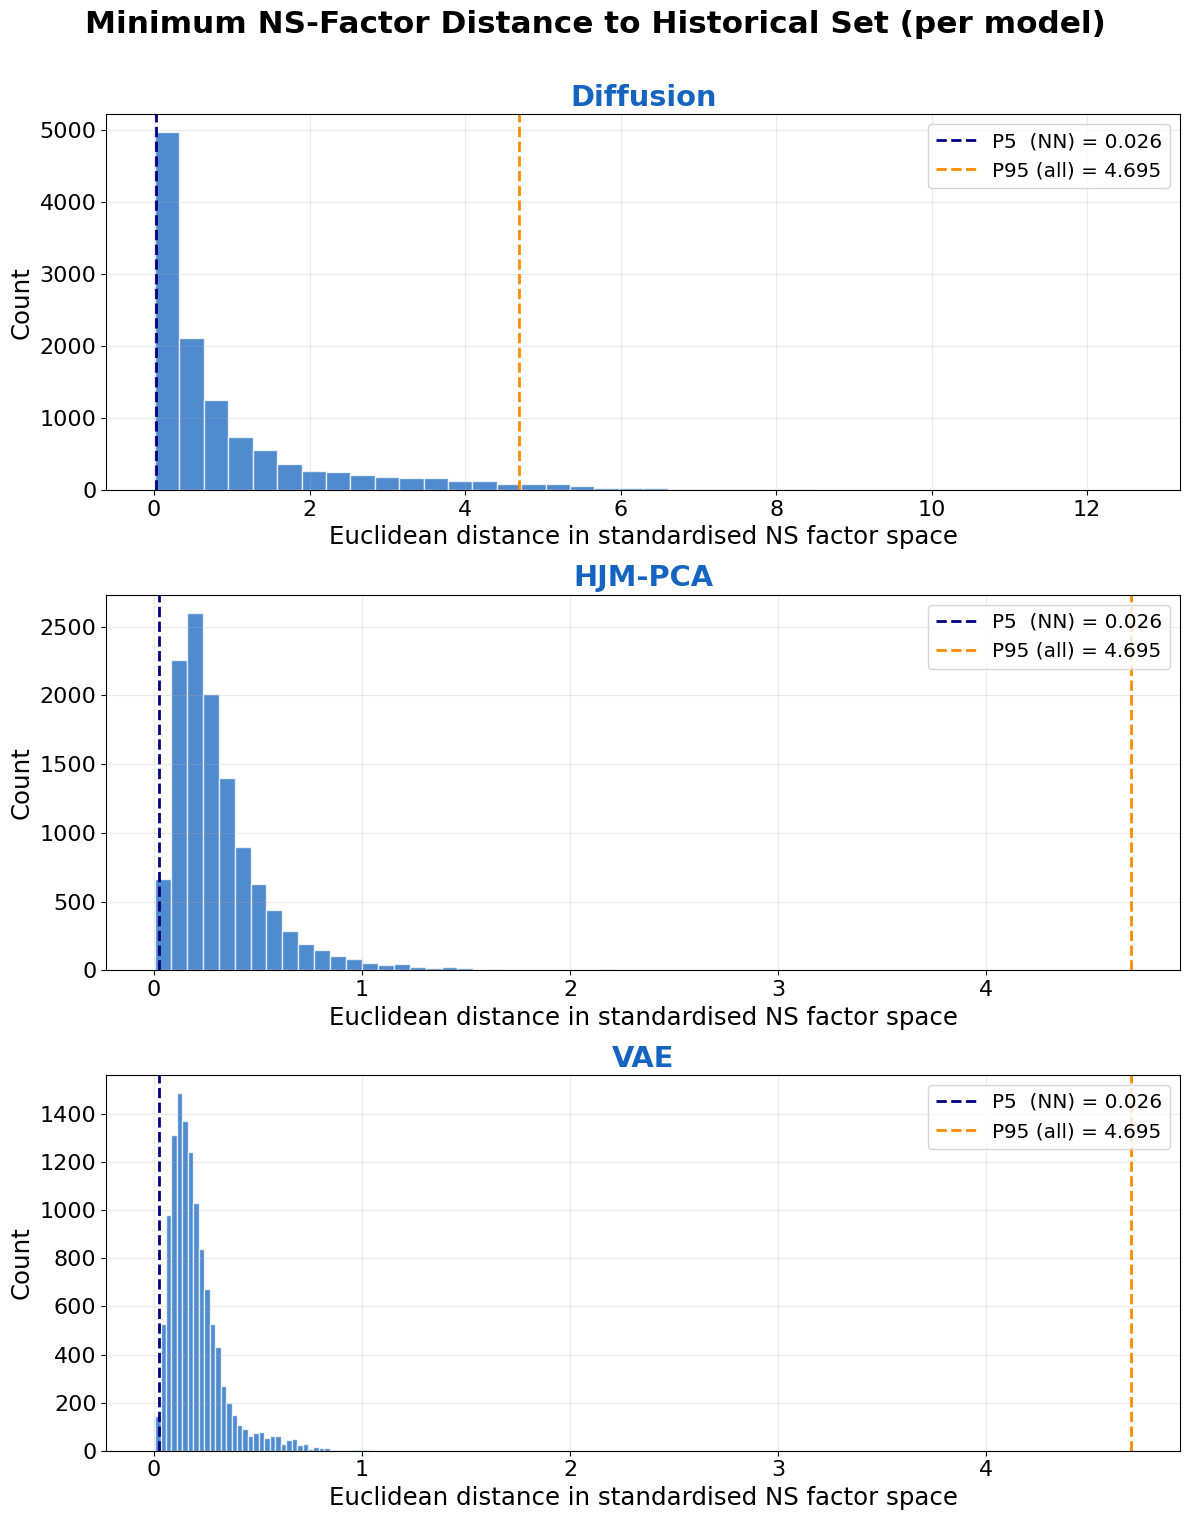

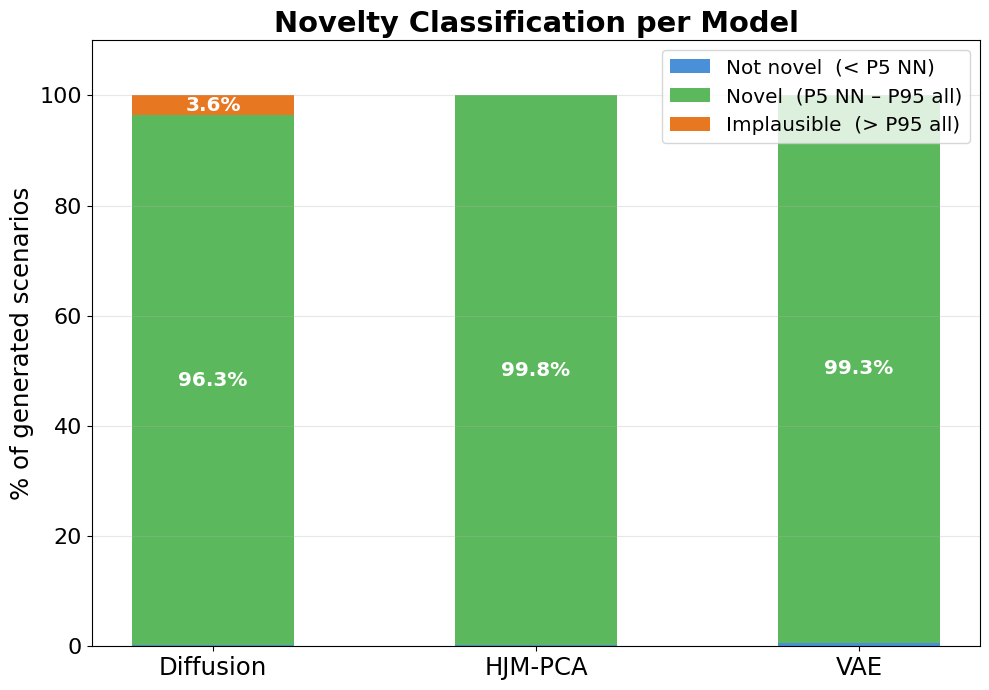

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ── file paths ────────────────────────────────────────────────────────────────
# Reuse the file paths defined at the start of the notebook.
HISTORICAL = historical_data

HIST_COLS = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
             "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]
SIM_COLS  = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
             "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]

# ── Nelson-Siegel setup ───────────────────────────────────────────────────────
LAMBDA   = 0.0609
MATS_YR  = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])

def ns_loadings(maturities, lam):
    """Returns (N_maturities, 3) loading matrix for β1, β2, β3."""
    lt  = lam * maturities
    L1  = np.ones_like(lt)
    L2  = (1 - np.exp(-lt)) / lt
    L3  = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

B = ns_loadings(MATS_YR, LAMBDA)

def fit_ns_factors(yields):
    """OLS fit of NS factors for each yield curve row. Returns (N, 3) array."""
    BtB_inv_Bt = np.linalg.lstsq(B, yields.T, rcond=None)[0].T
    return BtB_inv_Bt

# ── 1. load & convert historical data to NS factors ───────────────────────────
hist_ylds  = hist_monthly[HIST_COLS].dropna().values
hist_ns    = fit_ns_factors(hist_ylds)

print(f"Historical observations: {hist_ns.shape[0]}")

# ── 2. load & convert generated scenarios to NS factors ───────────────────────
def load_sim_ns(path):
    df = load_scenarios(path)
    return fit_ns_factors(df[SIM_COLS].dropna().values)

models = {name: load_sim_ns(path) for name, path in MODELS.items()}

# ── 3. standardise NS factors ─────────────────────────────────────────────────
hist_mean = hist_ns.mean(axis=0)
hist_std  = hist_ns.std(axis=0)

def standardise(factors):
    return (factors - hist_mean) / hist_std

hist_ns_z = standardise(hist_ns)
models    = {name: standardise(ns) for name, ns in models.items()}

# ── 4. calibrate thresholds ───────────────────────────────────────────────────
D_nn = cdist(hist_ns_z, hist_ns_z, metric="euclidean")
np.fill_diagonal(D_nn, np.inf)
nn_dists = D_nn.min(axis=1)
LOWER    = np.percentile(nn_dists, 5)

np.fill_diagonal(D_nn, 0)
all_dists = D_nn[np.triu_indices_from(D_nn, k=1)]
UPPER     = np.percentile(all_dists, 95)

print(f"Lower threshold (P5  of NN distances)      : {LOWER:.4f}")
print(f"Upper threshold (P95 of all pairwise dists): {UPPER:.4f}")

# ── 5. min distance of each generated curve to the historical NS set ──────────
def min_dist_to_hist(generated_ns_z, historical_ns_z):
    D = cdist(generated_ns_z, historical_ns_z, metric="euclidean")
    return D.min(axis=1)

model_dists = {name: min_dist_to_hist(ns_z, hist_ns_z)
               for name, ns_z in models.items()}

# ── Font sizes ────────────────────────────────────────────────────────────────
FS         = 1.6
TITLE_FS   = 13 * FS
LABEL_FS   = 11 * FS
TICK_FS    = 10 * FS
LEGEND_FS  = 9  * FS
SUPTITLE_FS= 14 * FS

BAR_COLOR  = "#1565C0"   # single colour used across all figures

# ── PLOT 1 — distance distributions, one row per model ───────────────────────
n_models = len(models)
fig1, axes1 = plt.subplots(n_models, 1, figsize=(12, 5 * n_models), sharex=False)
fig1.suptitle("Minimum NS-Factor Distance to Historical Set (per model)",
              fontsize=SUPTITLE_FS, fontweight="bold", y=1.01)

for ax, (name, dists) in zip(axes1, model_dists.items()):
    ax.hist(dists, bins=40, color=BAR_COLOR, alpha=0.75, edgecolor="white")
    ax.axvline(LOWER, color="navy",       ls="--", lw=2,
               label=f"P5  (NN) = {LOWER:.3f}")
    ax.axvline(UPPER, color="darkorange", ls="--", lw=2,
               label=f"P95 (all) = {UPPER:.3f}")
    ax.set_title(name, fontsize=TITLE_FS, fontweight="bold", color=BAR_COLOR)
    ax.set_xlabel("Euclidean distance in standardised NS factor space", fontsize=LABEL_FS)
    ax.set_ylabel("Count", fontsize=LABEL_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.legend(loc="upper right", fontsize=LEGEND_FS)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("novelty_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── PLOT 2 — stacked bar: % not novel / novel / implausible ──────────────────
labels, not_novel_pct, novel_pct, implaus_pct = [], [], [], []

for name, dists in model_dists.items():
    labels.append(name)
    not_novel_pct.append(100 * np.mean(dists < LOWER))
    novel_pct.append(    100 * np.mean((dists >= LOWER) & (dists <= UPPER)))
    implaus_pct.append(  100 * np.mean(dists > UPPER))

x = np.arange(len(labels))
w = 0.5

fig2, ax2 = plt.subplots(figsize=(10, 7))
b1 = ax2.bar(x, not_novel_pct, w, label="Not novel  (< P5 NN)",     color="#4A90D9")
b2 = ax2.bar(x, novel_pct,     w, bottom=not_novel_pct,
             label="Novel  (P5 NN – P95 all)",  color="#5CB85C")
b3 = ax2.bar(x, implaus_pct,   w,
             bottom=[a + b for a, b in zip(not_novel_pct, novel_pct)],
             label="Implausible  (> P95 all)",  color="#E87722")

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=LABEL_FS)
ax2.set_ylabel("% of generated scenarios", fontsize=LABEL_FS)
ax2.set_title("Novelty Classification per Model",
              fontsize=TITLE_FS, fontweight="bold")
ax2.legend(loc="upper right", fontsize=LEGEND_FS)
ax2.set_ylim(0, 110)
ax2.tick_params(axis="y", labelsize=TICK_FS)
ax2.grid(axis="y", alpha=0.3)

for i in range(len(labels)):
    cumulative = 0
    for vals in [not_novel_pct, novel_pct, implaus_pct]:
        h = vals[i]
        if h > 3:
            ax2.text(i, cumulative + h / 2, f"{h:.1f}%",
                     ha="center", va="center",
                     fontsize=LEGEND_FS, fontweight="bold", color="white")
        cumulative += h

plt.tight_layout()
plt.savefig("novelty_bars.png", dpi=150, bbox_inches="tight")
plt.show()